# 🌦️ SkyCheck — your weather & travel briefing

**Run All, then scroll.** This notebook answers the questions normal people actually ask about the weather:

| | Question | Where |
|---|---|---|
| 🌧️ | *What's coming at me right now?* | Full-screen live map: animated radar, warnings, wind |
| ✈️ | *Is weather going to mess with my flight today?* | Your closest airports + the big hubs |
| ⛈️ | *Are there storms anywhere I'm flying through?* | Live NOAA warning areas on the map |
| 🛸 | *When's the best time to be outside — or fly my drone — near home?* | 48-hour go / no-go timeline |
| 🗓️ | *Where and when is the weather actually nice?* | 12-month "nice days" calendar |

It **figures out where you are** automatically and centers everything on you. Everything is in **°F, mph, miles and inches**, colored the same way everywhere: 🟢 good · 🟠 heads-up · 🔴 problem.
Live data comes from NOAA's Aviation Weather Center and Open-Meteo — free, no API keys. If a source can't be reached, the notebook keeps working with clearly-labeled demo data.

## ⚙️ Your settings
Change these to your home, your airports, and what *you* call a nice day — then **Run All**.

In [1]:
# 📍 Where are you?
#   "auto"            -> figure it out from this computer's internet connection
#   "Pittsburgh, PA"  -> any place name
#   "40.44, -79.99"   -> exact coordinates
# An app running this notebook can also pass the viewer's location in the SKYCHECK_LOCATION environment variable.
LOCATION = "auto"
FALLBACK_LOCATION = ("Akron, OH", 41.08, -81.52)   # only used if detection fails
NEARBY_AIRPORTS = 2                                # your closest airports get added automatically
CARTO_API_KEY = ""   # optional: a free key from carto.com/basemaps/apikey switches the map to CARTO; blank = keyless Esri
MAP_URL = ""         # optional: where skycheck_map.html is served, if not auto-detected from the Jupyter server

# Other airports you care about — 4-letter codes (US airports: add a "K", e.g. CLE -> KCLE)
MY_AIRPORTS = ["KORD", "KATL", "KJFK", "KBOS", "KDFW", "KDEN", "KSEA", "KSFO", "KLAX", "KMIA"]

# Cities to compare in "when is the weather nicest?" (your own city is added automatically)
CLIMATE_CITIES = {
    "New York":    (40.71,  -74.01),
    "Chicago":     (41.88,  -87.63),
    "Denver":      (39.74, -104.99),
    "Seattle":     (47.61, -122.33),
    "Los Angeles": (34.05, -118.24),
    "Miami":       (25.76,  -80.19),
}

# A "nice day" = daytime high in this range (°F) and basically dry
NICE_HIGH_MIN, NICE_HIGH_MAX = 65, 85

# Drone / outdoor go-no-go limits (typical for small consumer drones — tune for yours)
DRONE = dict(max_wind=15, max_gust=20,      # mph
             max_rain_chance=20,            # %
             min_visibility=3,              # miles (FAA recreational minimum)
             min_temp=32, max_temp=95,      # °F — batteries hate cold, electronics hate heat
             daylight_only=True)

HOURS_AHEAD = 48

<details><summary><b>🔧 Behind the scenes</b> — data fetching and the plain-English translators (click to peek, or just run it)</summary>

This cell turns raw aviation shorthand like `+TSRA BKN025` into *"heavy thunderstorms with rain · mostly cloudy"*, decides what counts as a delay risk, and builds demo data for when a source is offline.
</details>

In [2]:
import math, random, warnings, json, os, re, html as _html
from datetime import datetime, timedelta, timezone
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle
from IPython.display import display, HTML
warnings.filterwarnings("ignore")
%matplotlib inline

NOW_UTC = datetime.now(timezone.utc)
HOME_OFFSET = timedelta(0)          # replaced once the home forecast loads
FONT = "system-ui,-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif"

# ---------- one visual language for the whole notebook ----------
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "-",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.labelcolor": "#555", "xtick.color": "#555", "ytick.color": "#555",
})
STATUS = {
    "good":    dict(label="Looking good",    emoji="✅", color="#1a9850", bg="#e6f5ea"),
    "watch":   dict(label="Possible delays", emoji="⚠️", color="#e08a00", bg="#fff3dc"),
    "bad":     dict(label="Delays likely",   emoji="🛑", color="#d73027", bg="#fde8e6"),
    "unknown": dict(label="No data",         emoji="❔", color="#9a9a9a", bg="#f1f1f1"),
}
RANK = {"unknown": -1, "good": 0, "watch": 1, "bad": 2}
GO = {"go": ("#1a9850", "Go"), "maybe": ("#f4a300", "Marginal"), "no": ("#d73027", "No-go")}
PILOT_COLORS = {"VFR": "#2ca02c", "MVFR": "#1f77b4", "IFR": "#d62728", "LIFR": "#c51bc5"}  # FAA/AWC standard

AIRPORT_INFO = {  # friendly names + fallback coordinates
    "KCAK": ("Akron-Canton", 40.916, -81.443),   "KCLE": ("Cleveland", 41.411, -81.849),
    "KORD": ("Chicago O'Hare", 41.978, -87.905), "KATL": ("Atlanta", 33.637, -84.428),
    "KJFK": ("New York JFK", 40.640, -73.779),   "KBOS": ("Boston Logan", 42.364, -71.005),
    "KDFW": ("Dallas/Fort Worth", 32.897, -97.038), "KDEN": ("Denver", 39.856, -104.674),
    "KSEA": ("Seattle-Tacoma", 47.450, -122.309), "KSFO": ("San Francisco", 37.619, -122.375),
    "KLAX": ("Los Angeles", 33.943, -118.408),   "KMIA": ("Miami", 25.793, -80.291),
}

# ---------- fetching (with real SSL verification + graceful fallback) ----------
DATA_SOURCES = {}
def fetch_json(label, url, params=None, demo=None, empty_ok=False):
    try:
        r = requests.get(url, params=params, timeout=20, headers={"User-Agent": "SkyCheck-notebook/2.0"})
        if r.status_code == 204 or not r.text.strip():
            if empty_ok:
                DATA_SOURCES[label] = "live"; return []
            raise ValueError("empty response")
        r.raise_for_status()
        DATA_SOURCES[label] = "live"
        return r.json()
    except Exception as e:
        DATA_SOURCES[label] = f"demo · {type(e).__name__}"
        return demo() if demo else None

def show_sources():
    groups = {}
    for k, v in DATA_SOURCES.items():
        g = "Climate history · Open-Meteo" if k.startswith("Climate") else k
        groups.setdefault(g, []).append(v == "live")
    chips, any_demo = [], False
    for g, oks in groups.items():
        ok = all(oks); any_demo |= not ok
        col = "#1a9850" if ok else "#e08a00"
        txt = "live" if ok else ("partly demo" if any(oks) else "DEMO data")
        chips.append(f"<span style='display:inline-block;margin:3px;padding:4px 10px;border-radius:20px;"
                     f"background:{col}1a;color:{col};font:600 12px {FONT}'>● {g}: {txt}</span>")
    warn = ("<div style='margin-top:6px;color:#b36b00;font:13px "+FONT+"'>⚠️ Some sources couldn't be reached, so parts of "
            "this briefing use <b>made-up demo data</b>. Re-run when you're online.</div>") if any_demo else ""
    display(HTML(f"<div>{''.join(chips)}{warn}</div>"))

# ---------- small helpers ----------
def num(x):
    try: return float(x)
    except (TypeError, ValueError): return None
def c_to_f(c):   return None if c is None else c * 9 / 5 + 32
def kt_to_mph(k): return None if k is None else k * 1.15078
def to_utc(t):
    if t is None or t == "": return None
    if isinstance(t, (int, float)): return datetime.fromtimestamp(t, timezone.utc)
    try: return pd.to_datetime(t, utc=True).to_pydatetime()
    except Exception: return None
def local(dt):  # UTC -> home local (naive)
    return None if dt is None else (dt + HOME_OFFSET).replace(tzinfo=None)
def hr_label(t, day=True):
    if t is None or pd.isna(t): return "—"
    h = int(t.strftime("%I")); ap = t.strftime("%p").lower()
    return f"{t:%a} {h}{ap}" if day else f"{h}{ap}"
def compass(deg):
    d = num(deg)
    if d is None: return "variable directions"
    return ["N","NNE","NE","ENE","E","ESE","SE","SSE","S","SSW","SW","WSW","W","WNW","NW","NNW"][int((d % 360) / 22.5 + 0.5) % 16]
def parse_vis(v):
    if v is None: return None
    if isinstance(v, (int, float)): return float(v)
    s = str(v).replace("+", "").replace("SM", "").strip()
    try:
        if " " in s: w, f = s.split(); a, b = f.split("/"); return float(w) + float(a) / float(b)
        if "/" in s: a, b = s.split("/"); return float(a) / float(b)
        return float(s)
    except Exception: return None
def ceiling_ft(clouds):
    b = [num(c.get("base")) for c in (clouds or []) if c.get("cover") in ("BKN", "OVC", "VV", "OVX")]
    b = [x for x in b if x is not None]
    return min(b) if b else None
def pilot_category(ceil, vis):
    if (ceil is not None and ceil < 500) or (vis is not None and vis < 1):  return "LIFR"
    if (ceil is not None and ceil < 1000) or (vis is not None and vis < 3): return "IFR"
    if (ceil is not None and ceil <= 3000) or (vis is not None and vis <= 5): return "MVFR"
    return "VFR"
_SKY_ORDER = ["SKC", "CLR", "CAVOK", "NSC", "FEW", "SCT", "BKN", "OVC", "OVX", "VV"]
_SKY = {"SKC": "Clear", "CLR": "Clear", "CAVOK": "Clear", "NSC": "Clear", "FEW": "Mostly clear",
        "SCT": "Partly cloudy", "BKN": "Mostly cloudy", "OVC": "Overcast", "OVX": "Sky hidden", "VV": "Fogged in"}
def sky_words(clouds):
    if not clouds: return "Clear"
    worst = max(clouds, key=lambda c: _SKY_ORDER.index(c.get("cover")) if c.get("cover") in _SKY_ORDER else 0)
    return _SKY.get(worst.get("cover"), "Cloudy")

_PHEN = {"RA": "rain", "SN": "snow", "DZ": "drizzle", "GR": "hail", "GS": "small hail", "PL": "ice pellets",
         "SG": "snow grains", "IC": "ice crystals", "UP": "precipitation", "FG": "fog", "BR": "mist", "HZ": "haze",
         "FU": "smoke", "DU": "dust", "SA": "sand", "VA": "volcanic ash", "SQ": "squalls", "FC": "funnel cloud",
         "PO": "dust whirls", "SS": "sandstorm", "DS": "duststorm"}
_DESC = {"TS", "SH", "FZ", "BL", "DR", "MI", "BC", "PR"}
def wx_words(wx):
    """'+TSRA -SN BR' -> ['heavy thunderstorms with rain', 'light snow', 'mist']"""
    out = []
    for tok in str(wx or "").split():
        inten = ""
        if tok.startswith("+"): inten, tok = "heavy ", tok[1:]
        elif tok.startswith("-"): inten, tok = "light ", tok[1:]
        near = tok.startswith("VC")
        if near: tok = tok[2:]
        parts = [tok[i:i + 2] for i in range(0, len(tok), 2)]
        desc = [p for p in parts if p in _DESC]
        words = " & ".join(_PHEN[p] for p in parts if p in _PHEN)
        if "FZ" in desc and words: words = "freezing " + words
        if "BL" in desc and words: words = "blowing " + words
        if "SH" in desc and words: words += " showers"
        if "TS" in desc: words = "thunderstorms" + (" with " + words if words else "")
        if words: out.append((inten + words + (" nearby" if near else "")).strip())
    return out
def wx_severity(wx):
    s = str(wx or "")
    if any(k in s for k in ("TS", "GR", "GS", "FZ", "PL", "+SN", "SQ", "FC")): return "bad"
    if any(k in s for k in ("RA", "SN", "DZ", "FG", "SH", "UP", "FU")): return "watch"
    return "good"

def assess(cat, wx, wind_mph, gust_mph, in_storm=False):
    """Plain-English delay risk for a traveler, plus the reasons why."""
    status, reasons = "good", []
    def bump(s, why):
        nonlocal status
        if RANK[s] > RANK[status]: status = s
        reasons.append(why)
    words, sev = wx_words(wx), wx_severity(wx)
    if sev != "good": bump(sev, (words[0] if words else "precipitation").capitalize())
    if cat == "LIFR":  bump("bad", "Very low clouds / fog — arrivals slow way down")
    elif cat == "IFR": bump("watch", "Low clouds or poor visibility — fewer landings per hour")
    g, w = gust_mph or 0, wind_mph or 0
    if g >= 40 or w >= 35:   bump("bad", f"Strong winds (gusts to {max(g, w):.0f} mph)")
    elif g >= 30 or w >= 25: bump("watch", f"Gusty winds (to {max(g, w):.0f} mph)")
    if in_storm: bump("bad", "Inside an active NOAA thunderstorm warning")
    if not reasons: reasons.append("No weather concerns right now")
    return status, reasons

WMO = [((0,), "☀️", "Clear"), ((1,), "🌤️", "Mostly clear"), ((2,), "⛅", "Partly cloudy"), ((3,), "☁️", "Overcast"),
       ((45, 48), "🌫️", "Fog"), ((51, 53, 55, 56, 57), "🌦️", "Drizzle"), ((61, 63, 65, 66, 67), "🌧️", "Rain"),
       ((71, 73, 75, 77), "🌨️", "Snow"), ((80, 81, 82), "🌦️", "Showers"), ((85, 86), "🌨️", "Snow showers"),
       ((95, 96, 99), "⛈️", "Thunderstorms")]
def wmo(code, is_day=1):
    c = int(num(code) or 0)
    for codes, e, w in WMO:
        if c in codes:
            if not is_day and c in (0, 1): e = "🌙"
            return e, w
    return "🌡️", "—"

# ---------- storm warnings (SIGMETs) ----------
HAZARD_WORDS = {"CONVECTIVE": "Thunderstorms", "TS": "Thunderstorms", "TURB": "Severe turbulence", "ICE": "Severe icing",
                "IFR": "Low clouds / visibility", "MTN OBSCN": "Mountains hidden in cloud", "ASH": "Volcanic ash",
                "VA": "Volcanic ash", "TC": "Tropical cyclone", "DS": "Dust storm", "SS": "Sandstorm"}
def _in_ring(lon, lat, ring):
    inside, n = False, len(ring)
    for i in range(n):
        x1, y1 = ring[i][:2]; x2, y2 = ring[(i + 1) % n][:2]
        if (y1 > lat) != (y2 > lat) and lon < (x2 - x1) * (lat - y1) / ((y2 - y1) or 1e-12) + x1:
            inside = not inside
    return inside
def in_geom(lon, lat, geom):
    t, c = (geom or {}).get("type"), (geom or {}).get("coordinates") or []
    polys = [c] if t == "Polygon" else (c if t == "MultiPolygon" else [])
    return any(p and _in_ring(lon, lat, p[0]) for p in polys)
def build_storms(sig):
    feats = sig.get("features", []) if isinstance(sig, dict) else (sig or [])
    out = []
    for f in feats:
        if not isinstance(f, dict) or not f.get("geometry"): continue
        p = f.get("properties") or {}
        if str(p.get("airSigmetType", "")).upper().startswith("AIRMET"): continue
        hz = str(p.get("hazard") or "").upper()
        kind = HAZARD_WORDS.get(hz, hz.title() or "Hazard")
        out.append(dict(feature=f, kind=kind, is_storm=(kind == "Thunderstorms"),
                        valid_to=to_utc(p.get("validTimeTo")), top=num(p.get("altitudeHi1") or p.get("altitudeHi2")),
                        move_dir=p.get("movementDir"), move_spd=num(p.get("movementSpd")), raw=p.get("rawAirSigmet", "")))
    return out

# ---------- airports right now (METAR) ----------
def build_airports(metars, storms):
    rows = {}
    for m in (metars or []):
        icao = m.get("icaoId") if isinstance(m, dict) else None
        if not icao: continue
        t = to_utc(m.get("reportTime") or m.get("obsTime"))
        if icao in rows and rows[icao]["obs_time"] and t and t <= rows[icao]["obs_time"]: continue
        info = AIRPORT_INFO.get(icao)
        name = info[0] if info else str(m.get("name", icao)).split(",")[0]
        lat = num(m.get("lat")) or (info[1] if info else None)
        lon = num(m.get("lon")) or (info[2] if info else None)
        vis, clouds = parse_vis(m.get("visib")), m.get("clouds") or []
        ceil = ceiling_ft(clouds)
        cat = m.get("fltCat") or pilot_category(ceil, vis)
        wind, gust = kt_to_mph(num(m.get("wspd"))), kt_to_mph(num(m.get("wgst")))
        in_storm = lat is not None and any(s["is_storm"] and in_geom(lon, lat, s["feature"]["geometry"]) for s in storms)
        status, reasons = assess(cat, m.get("wxString"), wind, gust, in_storm)
        age = (NOW_UTC - t).total_seconds() / 60 if t else None
        if age and age > 150: reasons.append(f"⏳ This report is {age / 60:.0f} hours old")
        rows[icao] = dict(icao=icao, name=name, lat=lat, lon=lon, obs_time=t, age_min=age,
                          temp_f=c_to_f(num(m.get("temp"))), wind_mph=wind, gust_mph=gust, wdir=m.get("wdir"),
                          vis_mi=vis, ceiling_ft=ceil, sky=sky_words(clouds), wx=m.get("wxString") or "",
                          cat=cat, status=status, reasons=reasons, in_storm=in_storm, raw=m.get("rawOb", ""))
    for icao in MY_AIRPORTS:
        if icao not in rows:
            n, la, lo = AIRPORT_INFO.get(icao, (icao, None, None))
            rows[icao] = dict(icao=icao, name=n, lat=la, lon=lo, obs_time=None, age_min=None, temp_f=None, wind_mph=None,
                              gust_mph=None, wdir=None, vis_mi=None, ceiling_ft=None, sky="—", wx="", cat="—",
                              status="unknown", reasons=["No recent report from this airport"], in_storm=False, raw="")
    df = pd.DataFrame(rows.values())
    df["rank"] = df.status.map(RANK)
    return df.sort_values(["rank", "icao"], ascending=[False, True]).reset_index(drop=True)

# ---------- airports next 24 h (TAF) ----------
def build_outlook(tafs, airports, hours=24):
    t0 = NOW_UTC.replace(minute=0, second=0, microsecond=0)
    hrs = [t0 + timedelta(hours=h) for h in range(hours)]
    grid, notes = {}, {}
    for taf in (tafs or []):
        icao = taf.get("icaoId") if isinstance(taf, dict) else None
        periods = [(to_utc(p.get("timeFrom")), to_utc(p.get("timeTo")), p) for p in (taf.get("fcsts") or []) if isinstance(p, dict)] if icao else []
        periods = [x for x in periods if x[0] and x[1]]
        if not periods: continue
        row, whys = [], []
        for h in hrs:
            mid = h + timedelta(minutes=30)
            cover = [p for a, b, p in periods if a <= mid < b]
            base = [p for p in cover if str(p.get("fcstChange") or "FM").upper() in ("FM", "BECMG")]
            temp = [p for p in cover if str(p.get("fcstChange") or "").upper() in ("TEMPO", "PROB")]
            if not cover: row.append("unknown"); whys.append(None); continue
            b = base[-1] if base else {}
            best, why = "good", None
            for cand in [b] + [{**b, **{k: v for k, v in t.items() if v not in (None, "", [])}} for t in temp]:
                cat = pilot_category(ceiling_ft(cand.get("clouds")), parse_vis(cand.get("visib")))
                s, r = assess(cat, cand.get("wxString"), kt_to_mph(num(cand.get("wspd"))), kt_to_mph(num(cand.get("wgst"))))
                if RANK[s] > RANK[best] or why is None: 
                    if RANK[s] >= RANK[best]: best, why = s, r[0]
            row.append(best); whys.append(why)
        grid[icao] = row
        worst = max(row, key=lambda s: RANK[s])
        if worst in ("watch", "bad"):
            i = row.index(worst); notes[icao] = (worst, hrs[i], whys[i])
    order = [i for i in airports.icao if i in MY_AIRPORTS]
    out = pd.DataFrame({i: grid.get(i, ["unknown"] * hours) for i in order}, index=hrs).T
    return out, notes

# ---------- home 48 h + drone go/no-go ----------
def build_home(fc, hours=HOURS_AHEAD):
    h = pd.DataFrame(fc["hourly"]); h["time"] = pd.to_datetime(h["time"])
    now_local = local(NOW_UTC)
    h = h[h.time >= now_local.replace(minute=0, second=0, microsecond=0)].head(hours).reset_index(drop=True)
    h["precipitation_probability"] = h["precipitation_probability"].fillna(0)
    h["precipitation"] = h["precipitation"].fillna(0)
    h["vis_mi"] = h["visibility"].fillna(99999) / 1609.34
    h["is_day"] = h["is_day"].fillna(1).astype(int)
    verdict, why = [], []
    for r in h.itertuples():
        hard, soft = [], []
        if DRONE["daylight_only"] and not r.is_day: hard.append("dark")
        w, g, pp = r.wind_speed_10m, r.wind_gusts_10m, r.precipitation_probability
        if w > DRONE["max_wind"] + 5 or g > DRONE["max_gust"] + 8: hard.append(f"too windy (gusts {g:.0f} mph)")
        elif w > DRONE["max_wind"] or g > DRONE["max_gust"]:      soft.append(f"gusty ({g:.0f} mph)")
        if r.precipitation >= 0.01 or pp > 2 * DRONE["max_rain_chance"]: hard.append(f"rain likely ({pp:.0f}%)")
        elif pp > DRONE["max_rain_chance"]:                              soft.append(f"{pp:.0f}% rain chance")
        if r.vis_mi < DRONE["min_visibility"]: hard.append("poor visibility")
        if not DRONE["min_temp"] <= r.temperature_2m <= DRONE["max_temp"]: soft.append(f"{r.temperature_2m:.0f}°F is hard on batteries")
        verdict.append("no" if hard else "maybe" if soft else "go")
        why.append(", ".join(hard + soft) or "all clear")
    h["verdict"], h["why"] = verdict, why
    return h, now_local

def best_window(h, ok=("go",)):
    best, cur = None, None
    for i, v in enumerate(h.verdict):
        if v in ok:
            cur = (cur[0], i) if cur else (i, i)
            if best is None or cur[1] - cur[0] > best[1] - best[0]: best = cur
        else: cur = None
    return best

def go_windows(h, min_hours=2):
    """(next, longest) runs of 'go' hours, each as (start_idx, end_idx) — next is what you can act on soonest."""
    runs, start = [], None
    for i, v in enumerate(list(h.verdict) + ["end"]):
        if v == "go" and start is None: start = i
        elif v != "go" and start is not None:
            if i - start >= min_hours: runs.append((start, i - 1))
            start = None
    if not runs: return None, None
    return runs[0], max(runs, key=lambda r: r[1] - r[0])

# ---------- 12-month climate ----------
def build_climate(raw):
    rows = []
    for city, js in raw.items():
        d = pd.DataFrame(js["daily"]); d["time"] = pd.to_datetime(d["time"])
        d = d.dropna(subset=["temperature_2m_max"])
        rain = d["precipitation_sum"].fillna(0)
        d["nice"] = d.temperature_2m_max.between(NICE_HIGH_MIN, NICE_HIGH_MAX) & (rain < 0.04)
        d["rainy"] = rain >= 0.04
        d["month"] = d.time.dt.month
        g = d.groupby("month").agg(high=("temperature_2m_max", "mean"), low=("temperature_2m_min", "mean"),
                                   nice=("nice", "sum"), rain_days=("rainy", "sum"), precip=("precipitation_sum", "sum"),
                                   sun=("sunshine_duration", "mean"))
        g["sun"] = g["sun"] / 3600; g["city"] = city
        rows.append(g.reset_index())
    return pd.concat(rows, ignore_index=True)

# ---------- demo data (used only when a live source can't be reached) ----------
def demo_metars():
    rng = random.Random(7)
    scen = {"KORD": ("+TSRA", [{"cover": "BKN", "base": 2500}, {"cover": "OVC", "base": 6000}], 3, 18, 38),
            "KSEA": ("-RA BR", [{"cover": "OVC", "base": 800}], 2.5, 8, 0),
            "KSFO": ("BR", [{"cover": "OVC", "base": 400}], 1.5, 6, 0),
            "KDEN": ("", [{"cover": "SCT", "base": 9000}], 10, 24, 36)}
    out = []
    for icao in MY_AIRPORTS:
        if icao not in AIRPORT_INFO: continue
        name, lat, lon = AIRPORT_INFO[icao]
        wx, clouds, vis, wspd, wgst = scen.get(icao, ("", [{"cover": rng.choice(["FEW", "SCT"]), "base": rng.choice([4000, 6000, 12000])}],
                                                     10, rng.randint(3, 12), 0))
        t = round(29 - (lat - 25) * 0.7 + rng.uniform(-3, 3), 1)
        out.append(dict(icaoId=icao, name=name, reportTime=(NOW_UTC - timedelta(minutes=rng.randint(5, 50))).isoformat(),
                        temp=t, dewp=round(t - rng.uniform(2, 9), 1), wdir=rng.choice(range(10, 360, 10)), wspd=wspd,
                        wgst=wgst or None, visib="10+" if vis >= 10 else vis, clouds=clouds, wxString=wx,
                        lat=lat, lon=lon, rawOb=f"{icao} (demo observation) {wx}".strip()))
    return out
def demo_tafs():
    t0 = NOW_UTC.replace(minute=0, second=0, microsecond=0)
    ep = lambda h: int((t0 + timedelta(hours=h)).timestamp())
    good = lambda a, b: {"timeFrom": ep(a), "timeTo": ep(b), "fcstChange": None, "wspd": 8, "visib": "6+",
                         "wxString": None, "clouds": [{"cover": "SCT", "base": 5000}]}
    out = []
    for icao in MY_AIRPORTS:
        if icao not in AIRPORT_INFO: continue
        f = [good(0, 30)]
        if icao == "KORD": f.append({"timeFrom": ep(0), "timeTo": ep(5), "fcstChange": "TEMPO", "wxString": "+TSRA", "visib": 2,
                                     "wgst": 35, "clouds": [{"cover": "BKN", "base": 2000}]})
        if icao == "KDFW": f.append({"timeFrom": ep(8), "timeTo": ep(13), "fcstChange": "PROB", "wxString": "TSRA", "visib": 3})
        if icao == "KSEA": f[0].update({"wxString": "-RA", "clouds": [{"cover": "OVC", "base": 900}], "visib": 4})
        if icao == "KSFO": f = [{**good(0, 5), "wxString": "BR", "visib": 1, "clouds": [{"cover": "OVC", "base": 300}]},
                                {**good(5, 30), "fcstChange": "FM"}]
        if icao == "KCLE": f.append({"timeFrom": ep(14), "timeTo": ep(20), "fcstChange": "TEMPO", "wxString": "SHRA", "visib": 4})
        out.append({"icaoId": icao, "fcsts": f})
    return out
def demo_sigmets():
    iso = lambda h: (NOW_UTC + timedelta(hours=h)).isoformat()
    poly = lambda pts: {"type": "Polygon", "coordinates": [pts + [pts[0]]]}
    return {"type": "FeatureCollection", "features": [
        {"type": "Feature", "geometry": poly([[-89.6, 40.9], [-86.8, 40.9], [-86.8, 42.8], [-89.6, 42.8]]),
         "properties": {"airSigmetType": "SIGMET", "hazard": "CONVECTIVE", "validTimeTo": iso(2), "altitudeHi1": 45000,
                        "movementDir": 250, "movementSpd": 25, "rawAirSigmet": "DEMO"}},
        {"type": "Feature", "geometry": poly([[-100.5, 33.6], [-98.4, 33.6], [-98.4, 35.2], [-100.5, 35.2]]),
         "properties": {"airSigmetType": "SIGMET", "hazard": "CONVECTIVE", "validTimeTo": iso(2), "altitudeHi1": 41000,
                        "movementDir": 230, "movementSpd": 20, "rawAirSigmet": "DEMO"}},
        {"type": "Feature", "geometry": poly([[-109, 38], [-104.5, 38], [-104.5, 41.5], [-109, 41.5]]),
         "properties": {"airSigmetType": "SIGMET", "hazard": "TURB", "validTimeTo": iso(4), "rawAirSigmet": "DEMO"}}]}
def demo_forecast(lat, lon):
    off = -4 * 3600
    now_l = (NOW_UTC + timedelta(seconds=off)).replace(tzinfo=None)
    start = now_l.replace(hour=0, minute=0, second=0, microsecond=0)
    n = 72; times = [start + timedelta(hours=i) for i in range(n)]
    rng = np.random.default_rng(3); hr = np.array([t.hour for t in times]); day = np.arange(n) // 24
    temp = 66 + 11 * np.sin((hr - 9) / 24 * 2 * np.pi) - 2 * day + rng.normal(0, .8, n)
    rain = np.clip(5 + 65 * np.exp(-((np.arange(n) - 40) / 3.5) ** 2) + rng.normal(0, 3, n), 0, 100)
    wind = np.clip(6 + 6 * np.sin((hr - 8) / 24 * 2 * np.pi) + rng.normal(0, 1, n), 1, None); wind[36:44] += 8
    gust = wind * 1.6 + rng.normal(0, 1, n)
    isday = ((hr >= 7) & (hr < 20)).astype(int)
    code = np.where(rain > 55, 95, np.where(rain > 35, 61, np.where(isday == 1, 1, 0)))
    i = now_l.hour
    return {"utc_offset_seconds": off,
            "current": dict(temperature_2m=round(temp[i], 1), apparent_temperature=round(temp[i] - 2, 1), weather_code=int(code[i]),
                            wind_speed_10m=round(wind[i], 1), wind_gusts_10m=round(gust[i], 1), is_day=int(isday[i])),
            "hourly": dict(time=[t.strftime("%Y-%m-%dT%H:%M") for t in times], temperature_2m=temp.round(1).tolist(),
                           apparent_temperature=(temp - 2).round(1).tolist(), precipitation_probability=rain.round().tolist(),
                           precipitation=np.where(rain > 45, 0.05, 0.0).tolist(), wind_speed_10m=wind.round(1).tolist(),
                           wind_gusts_10m=gust.round(1).tolist(), visibility=[24000.0] * n, weather_code=code.tolist(),
                           is_day=isday.tolist())}
def demo_archive(lat, lon, start, end):
    days = pd.date_range(start, end, freq="D"); doy = days.dayofyear.values; n = len(days)
    rng = np.random.default_rng(int(abs(lat * 100)))
    west = lon < -115
    season = -np.cos((doy - 15) / 365 * 2 * np.pi)
    amp = 5 if lat < 28 else (7 if west and lat < 40 else 12 if west else 20)
    high = 84 - (lat - 25) * 1.05 + amp * season + rng.normal(0, 5, n)
    low = high - (20 if lon < -100 and not west else 14) + rng.normal(0, 3, n)
    p_rain = 0.08 if west and lat < 40 else (0.25 + 0.3 * -season if west else 0.28 + (0.12 * season if lat < 28 else 0))
    rain = np.where(rng.random(n) < p_rain, rng.exponential(0.3, n), 0)
    sun = 3600 * np.clip(8 + 3 * season - 5 * (rain > 0.04) + rng.normal(0, 1, n), 0, 14)
    return {"daily": {"time": [d.strftime("%Y-%m-%d") for d in days], "temperature_2m_max": high.round(1).tolist(),
                      "temperature_2m_min": low.round(1).tolist(), "precipitation_sum": rain.round(2).tolist(),
                      "sunshine_duration": sun.round().tolist()}}

# ---------- where are you? ----------
US_STATES = dict(AL="Alabama", AK="Alaska", AZ="Arizona", AR="Arkansas", CA="California", CO="Colorado", CT="Connecticut",
    DE="Delaware", FL="Florida", GA="Georgia", HI="Hawaii", ID="Idaho", IL="Illinois", IN="Indiana", IA="Iowa", KS="Kansas",
    KY="Kentucky", LA="Louisiana", ME="Maine", MD="Maryland", MA="Massachusetts", MI="Michigan", MN="Minnesota",
    MS="Mississippi", MO="Missouri", MT="Montana", NE="Nebraska", NV="Nevada", NH="New Hampshire", NJ="New Jersey",
    NM="New Mexico", NY="New York", NC="North Carolina", ND="North Dakota", OH="Ohio", OK="Oklahoma", OR="Oregon",
    PA="Pennsylvania", RI="Rhode Island", SC="South Carolina", SD="South Dakota", TN="Tennessee", TX="Texas", UT="Utah",
    VT="Vermont", VA="Virginia", WA="Washington", WV="West Virginia", WI="Wisconsin", WY="Wyoming", DC="District of Columbia")
STATE_ABBR = {v.lower(): k for k, v in US_STATES.items()}
CLOUD_HOSTS = ("amazon", "aws", "google", "microsoft", "azure", "digitalocean", "linode", "akamai", "hetzner", "ovh",
               "oracle", "cloudflare", "vultr", "alibaba")

def km(a_lat, a_lon, b_lat, b_lon):
    p = math.pi / 180
    h = math.sin((b_lat - a_lat) * p / 2) ** 2 + math.cos(a_lat * p) * math.cos(b_lat * p) * math.sin((b_lon - a_lon) * p / 2) ** 2
    return 12742 * math.asin(math.sqrt(h))
def in_us(lat, lon): return 18 <= lat <= 72 and -180 <= lon <= -64
def place_label(city, region, country):
    region = (region or "").strip()
    if country in ("US", "United States", "United States of America"):
        region = region.upper() if len(region) == 2 else STATE_ABBR.get(region.lower(), region)
        return f"{city}, {region}" if region else city
    return ", ".join(x for x in (city, country) if x)

def geocode(q):
    parts = [p.strip() for p in q.split(",")]
    js = fetch_json("Place lookup · Open-Meteo", "https://geocoding-api.open-meteo.com/v1/search",
                    {"name": parts[0], "count": 10, "language": "en", "format": "json"})
    res = (js or {}).get("results") or []
    if len(parts) > 1 and res:
        want = parts[1].lower(); full = US_STATES.get(parts[1].upper(), "").lower()
        hit = [r for r in res if want in (str(r.get("admin1", "")).lower(), str(r.get("country_code", "")).lower(),
                                          str(r.get("country", "")).lower()) or (full and str(r.get("admin1", "")).lower() == full)]
        res = hit or res
    if not res: return None
    r = res[0]
    return place_label(r.get("name"), r.get("admin1"), r.get("country_code")), float(r["latitude"]), float(r["longitude"])

IP_NOTE = ""
def ip_locate():
    """Where is this machine? Tries three free IP-geolocation services in turn."""
    global IP_NOTE
    tries = [("https://ipapi.co/json/", lambda j: (j["city"], j.get("region_code") or j.get("region"), j.get("country_code"),
                                                   j["latitude"], j["longitude"], j.get("org", ""))),
             ("https://ipinfo.io/json", lambda j: (j["city"], j.get("region"), j.get("country"),
                                                   *map(float, j["loc"].split(",")), j.get("org", ""))),
             ("http://ip-api.com/json/", lambda j: (j["city"], j.get("region"), j.get("countryCode"),
                                                    j["lat"], j["lon"], j.get("isp", "")))]
    for url, parse in tries:
        try:
            r = requests.get(url, timeout=8, headers={"User-Agent": "SkyCheck-notebook/2.1"}); r.raise_for_status()
            city, region, country, lat, lon, org = parse(r.json())
            if lat is None or lon is None: continue
            if any(c in str(org).lower() for c in CLOUD_HOSTS):
                IP_NOTE = (f"This notebook seems to be running on a cloud server ({org}), so that's the data center's "
                           "location — set LOCATION in the settings cell to your city.")
            return place_label(city, region, country), float(lat), float(lon)
        except Exception:
            continue
    return None

def resolve_location():
    env = os.environ.get("SKYCHECK_LOCATION", "").strip()
    q = env or str(LOCATION or "auto").strip()
    via = " (passed in by the app)" if env else ""
    if q.lower() != "auto":
        m = re.match(r"^\s*(-?\d+(?:\.\d+)?)\s*,\s*(-?\d+(?:\.\d+)?)\s*$", q)
        if m:
            lat, lon = float(m[1]), float(m[2])
            return f"{lat:.2f}°, {lon:.2f}°", lat, lon, "the coordinates you gave" + via
        g = geocode(q)
        if g: return (*g, f"the place you typed ({q})" + via)
        return (*FALLBACK_LOCATION, f"fallback — couldn't find “{q}”")
    g = ip_locate()
    if g: return (*g, "this computer's internet connection")
    return (*FALLBACK_LOCATION, "fallback — automatic detection didn't work")

def _clean_airport(name):
    n = str(name or "").split(",")[0]
    for a, b in (("Intl", "International"), ("Rgnl", "Regional"), ("Muni", "Municipal"), ("Arpt", "Airport"), ("Fld", "Field")):
        n = re.sub(rf"\b{a}\b", b, n)
    return n.strip()

def nearest_airports(lat, lon, n=2):
    """Closest airports that publish official forecasts (TAFs) — i.e. the ones people actually fly from."""
    if n <= 0: return []
    bbox = f"{lat - 1.3:.2f},{lon - 1.8:.2f},{lat + 1.3:.2f},{lon + 1.8:.2f}"
    js = fetch_json("Nearby airports · NOAA", "https://aviationweather.gov/api/data/taf", {"bbox": bbox, "format": "json"},
                    lambda: [{"icaoId": k, "name": v[0], "lat": v[1], "lon": v[2]} for k, v in AIRPORT_INFO.items()])
    cands = {}
    for t in (js or []):
        i, la, lo = t.get("icaoId"), num(t.get("lat")), num(t.get("lon"))
        if i and len(i) == 4 and la is not None and lo is not None: cands[i] = (t.get("name") or i, la, lo)
    ranked = sorted(cands.items(), key=lambda kv: km(lat, lon, kv[1][1], kv[1][2]))
    picks = [(i, v) for i, v in ranked if km(lat, lon, v[1], v[2]) <= 160][:n]
    for i, (nm, la, lo) in picks:
        AIRPORT_INFO.setdefault(i, (_clean_airport(nm), la, lo))
    return [i for i, _ in picks]

def fetch_alerts(lat, lon):
    if not in_us(lat, lon): return []
    js = fetch_json("Weather alerts · NWS", "https://api.weather.gov/alerts/active", {"point": f"{lat:.4f},{lon:.4f}"},
                    lambda: {"features": []}, empty_ok=True)
    out = []
    for f in (js or {}).get("features", []) if isinstance(js, dict) else []:
        p = f.get("properties") or {}
        out.append(dict(event=p.get("event", "Alert"), severity=p.get("severity", ""), headline=p.get("headline", ""),
                        expires=to_utc(p.get("ends") or p.get("expires")), instruction=p.get("instruction") or "",
                        description=p.get("description") or ""))
    order = {"Extreme": 0, "Severe": 1, "Moderate": 2, "Minor": 3}
    return sorted(out, key=lambda a: order.get(a["severity"], 4))
def alert_color(sev): return {"Extreme": "#8b0000", "Severe": "#d73027", "Moderate": "#e08a00"}.get(sev, "#1f77b4")

def airport_name(i): return AIRPORT_INFO.get(i, (i,))[0]

def wind_text(r):
    if r.wind_mph is None or pd.isna(r.wind_mph): return "wind —"
    if r.wind_mph < 3: return "calm"
    g = f", gusts {r.gust_mph:.0f}" if r.gust_mph and not pd.isna(r.gust_mph) and r.gust_mph > r.wind_mph + 5 else ""
    return f"{r.wind_mph:.0f} mph from the {compass(r.wdir)}{g}"

print("✅ Toolkit ready")

✅ Toolkit ready


<details><summary><b>🔧 Behind the scenes: the live map</b> — the full-screen map page (same presentation system as FIRST/STRIKE: MapLibre globe, dark HUD, lever rail). Run it and move on.</summary>

The map is one self-contained web page. Python hands it the airports, warnings and forecast as JSON; everything else (radar frames, satellite, aircraft) loads live in your browser.
</details>

In [3]:
MAP_TEMPLATE = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0, viewport-fit=cover">
<meta name="theme-color" content="#14181d">
<title>SKY/CHECK — live weather map</title>
<link rel="icon" href="data:,">
<link href="https://fonts.googleapis.com/css2?family=Barlow+Condensed:wght@500;600;700&family=IBM+Plex+Mono:wght@400;500;600&display=swap" rel="stylesheet">
<style>
  /* palette + type system carried over from FIRST/STRIKE */
  :root{
    --smoke:#14181d; --panel:#1b2027; --panel-2:#20262f; --line:#2c333e;
    --ash:#e8e4da; --ash-dim:#9aa2ad; --ash-faint:#5d6570;
    --ember:#ff6b35; --ember-hot:#ff3d1f; --ember-cool:#ffb347;
    --chart-magenta:#d05ca8; --window-ok:#8fbf6f; --sky:#6fd3e0;
    --sat:env(safe-area-inset-top,0px); --sab:env(safe-area-inset-bottom,0px);
    --sal:env(safe-area-inset-left,0px); --sar:env(safe-area-inset-right,0px);
  }
  *{box-sizing:border-box;margin:0;padding:0;-webkit-tap-highlight-color:transparent}
  html,body{height:100%}
  body{background:var(--smoke);color:var(--ash);font-family:'IBM Plex Mono',monospace;font-size:13px;overflow:hidden}
  #app{display:grid;grid-template-rows:calc(52px + var(--sat)) 1fr calc(26px + var(--sab));height:100vh;height:100dvh}
  header{display:flex;align-items:center;gap:18px;padding:var(--sat) calc(16px + var(--sar)) 0 calc(16px + var(--sal));border-bottom:1px solid var(--line);background:var(--panel)}
  .wordmark{font-family:'Barlow Condensed',sans-serif;font-weight:700;font-size:24px;letter-spacing:.06em;white-space:nowrap}
  .wordmark em{font-style:normal;color:var(--ember)}
  .tagline{font-size:10px;color:var(--ash-faint);letter-spacing:.14em;text-transform:uppercase;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}
  .stats{margin-left:auto;display:flex;gap:22px;align-items:center}
  .stat{text-align:right}
  .stat b{font-family:'Barlow Condensed',sans-serif;font-size:20px;font-weight:600;display:block;line-height:1;white-space:nowrap}
  .stat span{font-size:9px;color:var(--ash-dim);letter-spacing:.12em;text-transform:uppercase;white-space:nowrap}
  .hbtn{white-space:nowrap;flex-shrink:0;background:none;border:1px solid var(--line);color:var(--ash);font-family:'Barlow Condensed',sans-serif;
    font-size:14px;font-weight:600;letter-spacing:.08em;padding:6px 12px;border-radius:2px;cursor:pointer}
  .hbtn:hover{border-color:var(--ember);color:var(--ember)}

  main{display:grid;grid-template-columns:340px 1fr;min-height:0}
  #app.no-rail main{grid-template-columns:1fr}
  #app.immersive{grid-template-rows:0 1fr 0} #app.immersive header,#app.immersive footer{display:none}
  #app.no-rail #rail{display:none}
  #rail{border-right:1px solid var(--line);display:flex;flex-direction:column;min-height:0;background:var(--panel)}
  .tabs{display:flex;border-bottom:1px solid var(--line)}
  .tab{flex:1;text-align:center;padding:9px 0;cursor:pointer;font-family:'Barlow Condensed',sans-serif;
    font-size:14px;font-weight:600;letter-spacing:.12em;color:var(--ash-dim);border-bottom:2px solid transparent}
  .tab.active{color:var(--ash);border-bottom-color:var(--ember)}
  #list,#brief{overflow-y:auto;flex:1;scrollbar-width:thin;scrollbar-color:var(--line) transparent}
  #brief{display:none;padding:14px}
  .ap-card{padding:12px 14px;border-bottom:1px solid var(--line);cursor:pointer;transition:background .12s}
  .ap-card:hover{background:var(--panel-2)}
  .ap-card.active{background:var(--panel-2);box-shadow:inset 3px 0 0 var(--ember)}
  .fc-top{display:flex;justify-content:space-between;align-items:baseline;gap:8px}
  .fc-name{font-weight:600;font-size:12px;overflow:hidden;text-overflow:ellipsis;white-space:nowrap}
  .fc-temp{font-family:'Barlow Condensed',sans-serif;font-weight:700;font-size:22px;line-height:1;white-space:nowrap}
  .fc-meta{margin-top:5px;font-size:10.5px;color:var(--ash-dim);line-height:1.6}
  .tag{display:inline-block;padding:1px 6px;border-radius:2px;font-size:9px;letter-spacing:.1em;text-transform:uppercase;margin-right:6px}
  .kpi{display:grid;grid-template-columns:1fr 1fr;gap:10px;margin-bottom:16px}
  .kpi div{background:var(--panel-2);border:1px solid var(--line);border-radius:2px;padding:10px}
  .kpi b{font-family:'Barlow Condensed',sans-serif;font-size:21px;font-weight:700;display:block;line-height:1.1}
  .kpi span{font-size:9.5px;color:var(--ash-dim);letter-spacing:.08em;text-transform:uppercase}
  .note{font-size:10.5px;line-height:1.6;color:var(--ash-dim);border:1px solid var(--line);border-left:3px solid var(--ember);
    padding:9px 11px;border-radius:2px;background:var(--panel-2);margin-bottom:10px}
  .note b{color:var(--ash)}

  #mapWrap{position:relative;min-height:0}
  #mapWrap{background:#000;overflow:hidden}
  /* the sky behind the globe — three tiled plates at different apparent depths (FIRST/STRIKE 0.8) */
  #stars{position:absolute;inset:0;z-index:0;pointer-events:none;overflow:hidden;background:#02040a;transition:opacity .35s linear}
  #stars i{position:absolute;left:-60%;top:-60%;width:220%;height:220%;display:block;
    background-repeat:repeat;transform-origin:50% 50%;will-change:transform,background-position}
  #map{position:absolute;inset:0;background:transparent;z-index:1}
  #map .maplibregl-canvas{background:transparent}
  #windCanvas{position:absolute;inset:0;z-index:2;width:100%;height:100%;pointer-events:none}
  /* HUD layer: scanlines, vignette, corner brackets, compass, coords, radar scope */
  #hud{position:absolute;inset:0;z-index:5;pointer-events:none;font-family:'IBM Plex Mono',monospace}
  #hud::before{content:'';position:absolute;inset:0;background:repeating-linear-gradient(0deg,rgba(0,0,0,.075) 0 1px,transparent 1px 3px)}
  #hud::after{content:'';position:absolute;inset:0;background:radial-gradient(ellipse at center,transparent 58%,rgba(4,6,9,.6) 100%)}
  .hud-corner{position:absolute;width:38px;height:38px;border:1.5px solid rgba(255,107,53,.55)}
  .hud-corner.tl{top:5px;left:5px;border-right:0;border-bottom:0}
  .hud-corner.tr{top:5px;right:5px;border-left:0;border-bottom:0}
  .hud-corner.bl{bottom:5px;left:5px;border-right:0;border-top:0}
  .hud-corner.br{bottom:5px;right:5px;border-left:0;border-top:0}
  #hudCmp{position:absolute;left:50%;bottom:78px;transform:translateX(-50%);width:240px}
  #hudCmp .win{position:relative;height:26px;overflow:hidden;background:rgba(20,24,29,.72);border:1px solid var(--line);border-radius:2px}
  #hudCmpStrip{position:absolute;top:0;left:0;height:100%;width:1440px;will-change:transform}
  #hudCmpStrip i{position:absolute;bottom:0;width:1px;height:5px;background:var(--ash-faint)}
  #hudCmpStrip i.mid{height:8px} #hudCmpStrip i.big{height:11px;background:var(--ash-dim)}
  #hudCmpStrip i b{position:absolute;bottom:11px;left:-9px;width:18px;text-align:center;font-family:'Barlow Condensed',sans-serif;font-size:10px;font-weight:600;color:var(--ash);letter-spacing:.05em}
  #hudCmp .lub{position:absolute;left:50%;top:0;bottom:0;width:1.5px;background:var(--ember);transform:translateX(-50%);box-shadow:0 0 6px var(--ember)}
  #hudHdg{position:absolute;left:50%;top:-13px;transform:translateX(-50%);font-size:8.5px;color:var(--ember);background:var(--smoke);padding:0 5px;letter-spacing:.12em;line-height:12px;border:1px solid var(--line);white-space:nowrap}
  #hudCoords{position:absolute;left:12px;bottom:60px;font-size:8.5px;color:var(--ash-dim);background:rgba(20,24,29,.72);border:1px solid var(--line);padding:3px 7px;border-radius:2px;letter-spacing:.06em;white-space:pre}
  #hudRadar{position:absolute;right:54px;bottom:44px;width:140px;height:140px;border-radius:50%;border:1px solid var(--line);
    background:radial-gradient(circle at center,rgba(20,24,29,.92),rgba(20,24,29,.66));box-shadow:0 0 0 3px rgba(20,24,29,.55),0 0 24px rgba(0,0,0,.5)}
  /* lever rail */
  #levers{position:absolute;top:12px;left:calc(12px + var(--sal));z-index:6;display:flex;flex-direction:column;gap:6px}
  .lever,#leversToggle{background:var(--panel);border:1px solid var(--line);color:var(--ash-dim);font-family:'Barlow Condensed',sans-serif;
    font-size:12px;font-weight:600;letter-spacing:.1em;padding:7px 11px;border-radius:2px;cursor:pointer;text-align:left;min-width:132px}
  #leversToggle{color:var(--ash);font-size:13px;font-weight:700}
  .lever:hover{color:var(--ash);border-color:var(--ash-faint)}
  .lever.on{color:var(--ember);border-color:var(--ember);background:rgba(255,107,53,.08)}
  .lever small{display:block;font-family:'IBM Plex Mono',monospace;font-size:8px;letter-spacing:.05em;color:var(--ash-faint);font-weight:400;margin-top:1px}
  #levers.collapsed .lever{display:none}
  #status{position:absolute;top:12px;right:calc(12px + var(--sar));background:var(--panel);border:1px solid var(--line);padding:6px 10px;
    font-size:10px;color:var(--ash-dim);border-radius:2px;z-index:5;max-width:46%;transition:opacity .5s}
  #status.err{color:var(--ember-hot);border-color:var(--ember-hot)}
  #status.faded{opacity:0}
  /* radar timeline HUD (FIRST/STRIKE sim-HUD styling) */
  #radarHud{position:absolute;left:50%;transform:translateX(-50%);bottom:14px;z-index:6;background:var(--panel);
    border:1px solid var(--ember);border-radius:2px;padding:7px 12px;display:flex;align-items:center;gap:10px;width:min(560px,calc(100% - 24px))}
  #radarHud.hidden{display:none}
  .rbtn{background:none;border:1px solid var(--line);color:var(--ash);font-family:'Barlow Condensed',sans-serif;font-size:14px;font-weight:700;
    width:32px;height:30px;border-radius:2px;cursor:pointer}
  .rbtn:hover{border-color:var(--ember);color:var(--ember)}
  #rPlay{width:40px;background:var(--ember);color:#14181d;border-color:var(--ember)}
  #rSlider{flex:1;min-width:60px;accent-color:var(--ember)}
  #rWhen{min-width:104px;text-align:right}
  #rWhen b{font-family:'Barlow Condensed',sans-serif;font-size:20px;font-weight:700;color:var(--ember-cool);display:block;line-height:1.05}
  #rWhen b.fc{color:var(--sky)}
  #rWhen span{font-size:9px;color:var(--ash-dim);letter-spacing:.1em;text-transform:uppercase}
  #rSrc{font-family:'Barlow Condensed',sans-serif;font-size:11px;font-weight:600;letter-spacing:.08em;background:none;border:1px solid var(--line);
    color:var(--ash-dim);padding:3px 7px;border-radius:2px;cursor:pointer;white-space:nowrap}
  #rSrc:hover{color:var(--ember);border-color:var(--ember)}
  /* airport pills + home */
  .pill{font-family:'Barlow Condensed',sans-serif;font-size:13px;font-weight:700;letter-spacing:.04em;color:#14181d;padding:1px 7px;border-radius:2px;
    border:1px solid #14181d;cursor:pointer;white-space:nowrap;box-shadow:0 1px 6px rgba(0,0,0,.55)}
  .pill.unknown{color:var(--ash)}
  .home{width:12px;height:12px;border-radius:50%;background:var(--sky);border:2px solid #fff;animation:p 2s infinite}
  @keyframes p{0%{box-shadow:0 0 0 0 rgba(111,211,224,.7)}70%{box-shadow:0 0 0 16px rgba(111,211,224,0)}100%{box-shadow:0 0 0 0 rgba(111,211,224,0)}}
  .maplibregl-popup-content{background:var(--panel);color:var(--ash);font-family:'IBM Plex Mono',monospace;font-size:11px;border:1px solid var(--line);border-radius:3px;padding:10px 12px;max-width:300px}
  .maplibregl-popup-tip{border-top-color:var(--panel)!important;border-bottom-color:var(--panel)!important}
  /* detail card (FIRST/STRIKE fire-card) */
  #card{display:none;position:absolute;top:44px;right:calc(12px + var(--sar));z-index:7;width:322px;max-height:calc(100% - 120px);
    overflow-y:auto;background:var(--panel);border:1px solid var(--line);border-radius:3px;padding:10px 12px;font-size:11px}
  #cClose{position:absolute;top:6px;right:8px;background:none;border:none;color:var(--ash-dim);font-size:15px;cursor:pointer}
  #cClose:hover{color:var(--ember)}
  .popup-title{font-family:'Barlow Condensed',sans-serif;font-size:17px;font-weight:600;margin-bottom:2px;padding-right:22px}
  .popup-line{color:var(--ash-dim);line-height:1.6}
  .popup-line b{color:var(--ash);font-weight:500}
  .badge{display:inline-block;font-family:'Barlow Condensed',sans-serif;font-size:15px;font-weight:700;letter-spacing:.06em;
    padding:3px 9px;border:1px solid;border-radius:2px;margin:6px 0}
  .bigtemp{font-family:'Barlow Condensed',sans-serif;font-size:40px;font-weight:700;line-height:1;float:right;margin:14px 0 0 8px}
  .reasons{margin:6px 0 10px 16px;color:var(--ash);line-height:1.6}
  .links-label{color:var(--ash-faint);letter-spacing:.08em;text-transform:uppercase;font-size:8.5px;display:block;margin:8px 0 4px}
  .strip{display:grid;grid-template-columns:repeat(24,1fr);gap:1px;height:16px}
  .strip i{display:block;border-radius:1px}
  .strip-lab{display:flex;justify-content:space-between;font-size:8.5px;color:var(--ash-faint);margin-top:3px}
  details{margin-top:10px;color:var(--ash-dim)} summary{cursor:pointer}
  details code{display:block;white-space:pre-wrap;font-size:10px;margin-top:5px;color:var(--ash)}
  #railToggle{position:absolute;bottom:14px;left:calc(12px + var(--sal));z-index:7;background:var(--panel);border:1px solid var(--line);
    color:var(--ash);font-family:'Barlow Condensed',sans-serif;font-size:13px;font-weight:700;letter-spacing:.1em;padding:8px 14px;border-radius:2px;cursor:pointer}
  #railToggle:hover{border-color:var(--ember);color:var(--ember)}
  footer{display:flex;align-items:center;gap:14px;padding:0 calc(14px + var(--sar)) var(--sab) calc(14px + var(--sal));border-top:1px solid var(--line);
    background:var(--panel);font-size:9.5px;color:var(--ash-faint);white-space:nowrap;overflow:hidden}
  footer .dot{width:6px;height:6px;border-radius:50%;display:inline-block;margin-right:5px}
  footer .right{margin-left:auto}
  #overlay{position:fixed;inset:0;background:rgba(10,13,16,.88);z-index:50;display:flex;overflow-y:auto;padding:16px}
  #overlay.hidden{display:none}
  .intro{background:var(--panel);border:1px solid var(--line);border-radius:4px;max-width:660px;width:100%;padding:28px 30px;margin:auto}
  .intro h1{font-family:'Barlow Condensed',sans-serif;font-size:30px;font-weight:700;letter-spacing:.04em;margin-bottom:4px}
  .intro h1 em{font-style:normal;color:var(--ember)}
  .intro .lede{font-size:12.5px;color:var(--ash-dim);line-height:1.65;margin-bottom:20px}
  .steps{display:grid;grid-template-columns:1fr 1fr 1fr;gap:12px;margin-bottom:20px}
  .step{background:var(--panel-2);border:1px solid var(--line);border-radius:3px;padding:13px}
  .step h2{font-family:'Barlow Condensed',sans-serif;font-size:16px;font-weight:700;letter-spacing:.1em;margin-bottom:6px}
  .step:nth-child(1) h2{color:var(--ember-cool)} .step:nth-child(2) h2{color:var(--window-ok)} .step:nth-child(3) h2{color:var(--ember-hot)}
  .step p{font-size:10.5px;color:var(--ash-dim);line-height:1.6}
  .intro .fine{font-size:9.5px;color:var(--ash-faint);line-height:1.6;margin-bottom:16px}
  #startBtn{width:100%;background:var(--ember);border:none;color:#14181d;font-family:'Barlow Condensed',sans-serif;
    font-size:17px;font-weight:700;letter-spacing:.1em;padding:12px;border-radius:2px;cursor:pointer}
  @media (max-width:760px){
    main{grid-template-columns:1fr;grid-template-rows:1fr 42%}
    #app.no-rail main{grid-template-rows:1fr}
    #rail{order:2;border-right:none;border-top:1px solid var(--line)}
    header{gap:10px;padding-left:calc(12px + var(--sal));padding-right:calc(12px + var(--sar))}
    .wordmark{font-size:20px} .tagline{display:none}
    .stats{gap:10px} .stat b{font-size:16px} .stats .stat:nth-child(n+2){display:none}
    .hbtn{padding:5px 8px;font-size:12px}
    #status{max-width:58%;font-size:9px}
    #radarHud{gap:6px;padding:6px 8px}
    .rbtn{width:28px;height:28px} #rPlay{width:34px}
    #rWhen{min-width:74px} #rWhen b{font-size:15px} #rWhen span{font-size:8px}
    #rSrc{padding:3px 5px;font-size:10px}
    .lever{min-width:0;padding:6px 8px} .lever small{display:none} #leversToggle{min-width:0}
    #card{width:calc(100% - 24px);max-height:52%}
    #radarHud{bottom:56px}
    #hudCoords{display:none}
    #hudRadar{width:96px;height:96px;right:10px;bottom:150px}
    #hudCmp{width:180px;bottom:108px} #hudCmp .win{height:22px}
    #hud::before{background:repeating-linear-gradient(0deg,rgba(0,0,0,.05) 0 1px,transparent 1px 3px)}
    .hud-corner{width:26px;height:26px}
    .maplibregl-ctrl-bottom-right .maplibregl-ctrl-group{display:none}
    footer .fx{display:none}
    .steps{grid-template-columns:1fr}
  }
</style>
</head>
<body>
<div id="app" class="no-rail">
  <header>
    <div class="wordmark">SKY<em>/</em>CHECK</div>
    <div class="tagline">live radar · airports · warnings · <span id="homeName"></span></div>
    <div class="stats">
      <div class="stat" id="stTemp"><b>–</b><span>home now</span></div>
      <div class="stat" id="stAir"><b>–</b><span>airports w/ issues</span></div>
      <div class="stat" id="stStorm"><b>–</b><span>storm warnings</span></div>
      <div class="stat" id="stWin"><b>–</b><span>next good window</span></div>
    </div>
    <button class="hbtn" id="fsBtn" title="Full screen">⛶ FULL</button>
    <button class="hbtn" id="helpBtn">?</button>
  </header>
  <main>
    <div id="rail">
      <div class="tabs"><div class="tab active" data-t="list">AIRPORTS</div><div class="tab" data-t="brief">BRIEFING</div></div>
      <div id="list"></div>
      <div id="brief"></div>
    </div>
    <div id="mapWrap">
      <div id="stars"><i id="skyFar"></i><i id="skyMid"></i><i id="skyNear"></i></div>
      <div id="map"></div>
      <canvas id="windCanvas"></canvas>
      <div id="hud" aria-hidden="true">
        <div class="hud-corner tl"></div><div class="hud-corner tr"></div><div class="hud-corner bl"></div><div class="hud-corner br"></div>
        <div id="hudCmp"><div id="hudHdg">HDG 000°</div><div class="win"><div id="hudCmpStrip"></div><div class="lub"></div></div></div>
        <div id="hudCoords"></div>
        <canvas id="hudRadar" width="280" height="280"></canvas>
      </div>
      <div id="levers">
        <button id="leversToggle">☰ LEVERS</button>
        <button class="lever on" id="lvGlobe">GLOBE<small>orbital projection</small></button>
        <button class="lever on" id="lvRadar">RADAR<small>animated, last 2 hrs</small></button>
        <button class="lever on" id="lvStorms">WARNINGS<small>NOAA storm areas</small></button>
        <button class="lever on" id="lvWind">WIND<small>animated, live</small></button>
        <button class="lever" id="lvSat">SATELLITE<small>high-res imagery</small></button>
        <button class="lever" id="lvClouds">IR CLOUDS<small>infrared satellite</small></button>
        <button class="lever" id="lvTerrain">3D TERRAIN<small>topographic relief</small></button>
        <button class="lever" id="lvAir">LIVE AIRCRAFT<small>real planes overhead</small></button>
      </div>
      <div id="status">loading map…</div>
      <div id="card"></div>
      <div id="radarHud">
        <button class="rbtn" id="rPrev">◀</button>
        <button class="rbtn" id="rPlay">❚❚</button>
        <button class="rbtn" id="rNext">▶</button>
        <input type="range" id="rSlider" min="0" max="0" value="0">
        <div id="rWhen"><b>…</b><span>radar</span></div>
        <button id="rSrc" title="Switch radar source">🇺🇸 US HD</button>
      </div>
      <button id="railToggle">☰ AIRPORTS</button>
    </div>
  </main>
  <footer>
    <span><i class="dot" style="background:var(--window-ok)"></i>looking good</span>
    <span><i class="dot" style="background:var(--ember-cool)"></i>possible delays</span>
    <span><i class="dot" style="background:var(--ember-hot)"></i>delays likely</span>
    <span class="fx"><i class="dot" style="background:var(--ember-hot);border-radius:0;opacity:.6"></i>thunderstorm warning</span>
    <span class="fx"><i class="dot" style="background:var(--chart-magenta);border-radius:0;opacity:.6"></i>other hazard aloft</span>
    <span class="fx"><i class="dot" style="background:var(--sky)"></i>you</span>
    <span class="right" id="footNote"></span>
  </footer>
</div>
<div id="overlay" class="hidden">
  <div class="intro">
    <h1>SKY<em>/</em>CHECK</h1>
    <div class="lede">Everything moving in the sky around you, on one live map. Radar loops the last two hours so you can see which way the rain is heading. Airports are colored by how likely weather is to slow flights down. Shaded areas are official NOAA warnings.</div>
    <div class="steps">
      <div class="step"><h2>1 · WATCH</h2><p>The radar plays on its own. Brighter colors mean heavier rain. Drag the slider to scrub, or hit ▶ for the short forecast frames.</p></div>
      <div class="step"><h2>2 · CHECK</h2><p>Tap any airport for plain-English conditions and a 24-hour outlook strip. The ☰ AIRPORTS list sorts the worst first.</p></div>
      <div class="step"><h2>3 · AVOID</h2><p>Red shading is a thunderstorm warning; purple is turbulence or icing aloft. Tap one to see how long it lasts and where it's moving.</p></div>
    </div>
    <div class="fine">The levers on the left add satellite imagery, 3D terrain, and real aircraft flying right now. Radar by LibreWXR (falls back to RainViewer) worldwide, and NEXRAD via Iowa Environmental Mesonet (US). Basemap and imagery by Esri; daily clouds from NASA GIBS. No API keys anywhere. Airport data and warnings from NOAA's Aviation Weather Center. A planning aid, not an official flight briefing.</div>
    <button id="startBtn">SHOW ME THE MAP →</button>
  </div>
</div>
<script id="selfsrc" type="text/plain">__SELF__</script>
<script>const DATA = __DATA__;</script>
<script>
const $ = id => document.getElementById(id);
const ST = {good:{c:'#8fbf6f',l:'Looking good',e:'✅'}, watch:{c:'#ffb347',l:'Possible delays',e:'⚠️'},
            bad:{c:'#ff3d1f',l:'Delays likely',e:'🛑'}, unknown:{c:'#5d6570',l:'No data',e:'❔'}};
const esc = s => String(s ?? '').replace(/[&<>"]/g, c => ({'&':'&amp;','<':'&lt;','>':'&gt;','"':'&quot;'}[c]));
const toRad = d => d * Math.PI / 180;
let map = null, statusTimer = null;
const levers = {radar:true, storms:true, wind:true, sat:false, clouds:false, terrain:false, air:false};

function status(msg, err){
  const s = $('status'); s.textContent = msg; s.className = err ? 'err' : '';
  clearTimeout(statusTimer); statusTimer = setTimeout(() => s.classList.add('faded'), 7000);
}

/* ---------- header, rail, briefing ---------- */
function fillChrome(){
  const S = DATA.summary, H = DATA.home;
  $('homeName').textContent = H.name;
  $('stTemp').querySelector('b').textContent = H.temp != null ? H.emo + ' ' + H.temp + '°' : '–';
  const air = $('stAir').querySelector('b');
  air.textContent = S.n_issue + ' / ' + S.n_air;
  air.style.color = S.n_bad ? ST.bad.c : S.n_issue ? ST.watch.c : ST.good.c;
  const st = $('stStorm').querySelector('b');
  st.textContent = S.n_storm; st.style.color = S.n_storm ? ST.bad.c : ST.good.c;
  const w = $('stWin').querySelector('b'); w.textContent = S.window || 'none'; w.style.color = S.window ? ST.good.c : ST.watch.c;
  $('footNote').textContent = 'updated ' + DATA.stamp + ' · ' + DATA.sources;
  $('list').innerHTML = DATA.airports.map((a, i) => {
    const s = ST[a.status];
    return `<div class="ap-card" data-i="${i}"><div class="fc-top"><div class="fc-name">${a.near ? '📍 ' : ''}${esc(a.name)}</div>
      <div class="fc-temp" style="color:${s.c}">${a.temp != null ? a.temp + '°' : '–'}</div></div>
      <div class="fc-meta"><span class="tag" style="background:${s.c}22;color:${s.c}">${s.l}</span>${esc(a.icao)}<br>${esc(a.reasons[0] || '')}</div></div>`;
  }).join('');
  document.querySelectorAll('.ap-card').forEach(el => el.onclick = () => focusAirport(+el.dataset.i));
  const al = (DATA.alerts || []).map(a => `<div class="note" style="border-left-color:${a.color}">🚨 <b>${esc(a.event)}</b>${a.until ? ' until ' + esc(a.until) : ''}</div>`).join('');
  $('brief').innerHTML = al + `<div class="kpi">
      <div><b>${H.temp != null ? H.emo + ' ' + H.temp + '°F' : '–'}</b><span>${esc(H.words || '')} now</span></div>
      <div><b>${esc(S.umbrella)}</b><span>umbrella?</span></div>
      <div><b>${esc(S.wear)}</b><span>what to wear</span></div>
      <div><b>${esc(S.window || 'none soon')}</b><span>next good time outside</span></div></div>
    <div class="note"><b>${S.n_issue} of ${S.n_air} airports</b> have weather that could slow flights${S.n_bad ? ' — ' + S.n_bad + ' likely to see delays' : ''}.
      ${S.n_storm ? '<b>' + S.n_storm + ' thunderstorm warning' + (S.n_storm > 1 ? 's are' : ' is') + '</b> active.' : 'No thunderstorm warnings right now.'}</div>`;
  document.querySelectorAll('.tab').forEach(t => t.onclick = () => {
    document.querySelectorAll('.tab').forEach(x => x.classList.toggle('active', x === t));
    $('list').style.display = t.dataset.t === 'list' ? 'block' : 'none';
    $('brief').style.display = t.dataset.t === 'brief' ? 'block' : 'none';
  });
}
function setRail(open){
  $('app').classList.toggle('no-rail', !open);
  $('railToggle').textContent = open ? '✕ CLOSE LIST' : '☰ AIRPORTS';
  setTimeout(() => map && map.resize(), 60);
}
$('railToggle').onclick = () => setRail($('app').classList.contains('no-rail'));

/* ---------- airport detail card ---------- */
function openCard(i){
  const a = DATA.airports[i], s = ST[a.status], o = a.outlook || [];
  const cells = o.length ? o.map(x => `<i style="background:${ST[x].c}"></i>`).join('') : '';
  const L = DATA.outlook_labels || [];
  $('card').innerHTML = `<button id="cClose">✕</button>
    <div class="bigtemp" style="color:${s.c}">${a.temp != null ? a.temp + '°' : '–'}</div>
    <div class="popup-title">${esc(a.name)}</div>
    <div class="popup-line">${esc(a.icao)}${a.near ? ' · 📍 near you' : ''}${a.age ? ' · updated ' + esc(a.age) : ''}</div>
    <div class="badge" style="color:${s.c};border-color:${s.c};background:${s.c}1a">${s.e} ${s.l}</div>
    <div class="popup-line"><b>${esc(a.sky)}</b> · 💨 ${esc(a.wind)}</div>
    <ul class="reasons">${a.reasons.map(r => '<li>' + esc(r) + '</li>').join('')}</ul>
    ${cells ? `<span class="links-label">next 24 hours</span><div class="strip">${cells}</div>
      <div class="strip-lab">${[0, 6, 12, 18, 23].map(k => '<span>' + esc(L[k] || '') + '</span>').join('')}</div>` : ''}
    <details><summary>For pilots: <b style="color:${s.c}">${esc(a.cat)}</b></summary><code>${esc(a.raw)}</code></details>`;
  $('card').style.display = 'block';
  $('cClose').onclick = () => { $('card').style.display = 'none'; document.querySelectorAll('.ap-card').forEach(x => x.classList.remove('active')); };
  document.querySelectorAll('.ap-card').forEach(x => x.classList.toggle('active', +x.dataset.i === i));
}
function focusAirport(i){
  const a = DATA.airports[i];
  if (map && a.lat != null) map.flyTo({center:[a.lon, a.lat], zoom:Math.max(map.getZoom(), 6.5), duration:1600});
  openCard(i);
}

/* ---------- radar (RainViewer worldwide / NEXRAD US) ---------- */
let frames = [], fidx = 0, rTimer = null, hold = 0, rSrc = 'live';
function lastPast(){ let k = 0; frames.forEach((f, j) => { if (!f.fc) k = j; }); return k; }
function clearRadar(){
  frames.forEach((f, i) => { if (map.getLayer('rf' + i)) map.removeLayer('rf' + i); if (map.getSource('rf' + i)) map.removeSource('rf' + i); });
  frames = [];
}
function showFrame(i){
  if (!frames.length) return;
  const prev = fidx; fidx = i;
  if (map.getLayer('rf' + prev)) map.setPaintProperty('rf' + prev, 'raster-opacity', 0);
  if (map.getLayer('rf' + i)) map.setPaintProperty('rf' + i, 'raster-opacity', levers.radar ? .78 : 0);
  $('rSlider').value = i;
  const f = frames[i], rel = Math.round((f.t * 1000 - Date.now()) / 60000);
  const clock = new Date(f.t * 1000).toLocaleTimeString([], {hour:'numeric', minute:'2-digit'});
  $('rWhen').innerHTML = f.fc ? `<b class="fc">+${Math.max(rel, 0)} MIN</b><span>forecast · ${clock}</span>`
    : `<b>${i === lastPast() ? 'LATEST' : Math.abs(rel) + ' MIN AGO'}</b><span>radar · ${clock}</span>`;
}
function stop(){ clearInterval(rTimer); rTimer = null; $('rPlay').textContent = '▶'; }
function play(){
  stop(); $('rPlay').textContent = '❚❚';
  rTimer = setInterval(() => { if (fidx === frames.length - 1 && ++hold < 4) return; hold = 0; showFrame((fidx + 1) % frames.length); }, 600);
}
function buildRadar(fr){
  clearRadar(); frames = fr; fidx = 0;
  const before = map.getLayer('storm-fill') ? 'storm-fill' : 'labels';
  fr.forEach((f, i) => {
    map.addSource('rf' + i, {type:'raster', tiles:[f.url], tileSize:256, maxzoom:f.maxz, attribution:f.attr});
    map.addLayer({id:'rf' + i, type:'raster', source:'rf' + i, paint:{'raster-opacity':0, 'raster-fade-duration':0}}, before);
  });
  $('rSlider').max = fr.length - 1; showFrame(0); play();
}
const RADAR_SOURCES = [
  {name:'LibreWXR', url:'https://api.librewxr.net/public/weather-maps.json', color:4, maxz:10,
   attr:'Radar © <a href="https://librewxr.net" target="_blank">LibreWXR</a> (CC BY 4.0)'},
  {name:'RainViewer', url:'https://api.rainviewer.com/public/weather-maps.json', color:2, maxz:7,
   attr:'<a href="https://www.rainviewer.com" target="_blank">Weather data by RainViewer</a>'}];
async function useLive(){
  for (const src of RADAR_SOURCES){
    try {
      const r = await fetch(src.url); if (!r.ok) throw new Error(src.name + ' ' + r.status);
      const d = await r.json();
      const mk = (f, fc) => ({t:f.time, fc, maxz:src.maxz, attr:src.attr,
        url:(d.host || '') + f.path + '/256/{z}/{x}/{y}/' + src.color + '/1_1.png'});
      const fr = [...((d.radar || {}).past || []).map(f => mk(f, false)), ...((d.radar || {}).nowcast || []).map(f => mk(f, true))];
      if (!fr.length) throw new Error('no frames');
      rSrc = 'live'; $('rSrc').textContent = '🇺🇸 US HD'; buildRadar(fr);
      status('radar · ' + src.name + ' · ' + fr.length + ' frames' + (fr.some(f => f.fc) ? ' incl. forecast' : ''));
      return;
    } catch (e) { /* try the next source */ }
  }
  if (DATA.home.us){ status('worldwide radar unavailable — using US NEXRAD'); useUS(); }
  else status('radar services unavailable right now', true);
}
function useUS(){
  const now = Math.floor(Date.now() / 300000) * 300;
  const attr = 'NEXRAD via <a href="https://mesonet.agron.iastate.edu" target="_blank">Iowa Environmental Mesonet</a>';
  const fr = [50, 45, 40, 35, 30, 25, 20, 15, 10, 5, 0].map(m => ({t:now - m * 60, fc:false, maxz:9, attr,
    url:'https://mesonet.agron.iastate.edu/cache/tile.py/1.0.0/nexrad-n0q-900913' + (m ? '-m' + String(m).padStart(2, '0') + 'm' : '') + '/{z}/{x}/{y}.png'}));
  rSrc = 'us'; $('rSrc').textContent = '🌎 WORLD'; buildRadar(fr);
  status('radar · NEXRAD high-detail · last 50 minutes' + (DATA.home.us ? '' : ' (US coverage only)'));
}
$('rPlay').onclick = () => rTimer ? stop() : play();
$('rPrev').onclick = () => { stop(); showFrame((fidx - 1 + frames.length) % frames.length); };
$('rNext').onclick = () => { stop(); showFrame((fidx + 1) % frames.length); };
$('rSlider').oninput = e => { stop(); showFrame(+e.target.value); };
$('rSrc').onclick = () => rSrc === 'live' ? useUS() : useLive();

/* ---------- live aircraft (same community ADS-B chain as FIRST/STRIKE) ---------- */
const ADSB = [
  {name:'adsb.lol',       url:(la, lo, r) => `https://api.adsb.lol/v2/lat/${la}/lon/${lo}/dist/${r}`},
  {name:'airplanes.live', url:(la, lo, r) => `https://api.airplanes.live/v2/point/${la}/${lo}/${r}`},
  {name:'adsb.fi',        url:(la, lo, r) => `https://opendata.adsb.fi/api/v2/lat/${la}/lon/${lo}/dist/${r}`},
  {name:'OpenSky', url:(la, lo, r) => { const d = r / 60, e = d / Math.max(.2, Math.cos(toRad(la)));
     return `https://opensky-network.org/api/states/all?lamin=${(la - d).toFixed(2)}&lomin=${(lo - e).toFixed(2)}&lamax=${(+la + d).toFixed(2)}&lomax=${(+lo + e).toFixed(2)}`; },
   parse:d => (d.states || []).filter(s => s[5] != null && s[6] != null && !s[8]).map(s => ({lat:s[6], lon:s[5], gs:(s[9] || 0) * 1.944, track:s[10] || 0}))}];
let adsbIdx = 0, airTimer = null, airAnim = null, airData = [], airT = 0;
/* FIRST/STRIKE 0.8 notes: these APIs only send CORS headers on a *successful* reply, so a 429 or a
   Cloudflare challenge shows up as "blocked by CORS". Cool each provider down with backoff, cache
   replies for 25 s, and don't sweep at globe zoom. */
const ADSB_MIN_ZOOM = 3.2, adsbCool = new Map(), adsbCache = new Map();
function adsbStrike(p, hard){
  const c = adsbCool.get(p.name) || {until:0, strikes:0}; c.strikes = Math.min(6, c.strikes + 1);
  c.until = Date.now() + (hard ? 60000 : 15000) * Math.pow(2, c.strikes - 1); adsbCool.set(p.name, c);
}
async function adsbFetch(la, lo, r){
  const ck = la + ',' + lo + ',' + r, hit = adsbCache.get(ck);
  if (hit && Date.now() - hit.t < 25000) return hit.res;
  for (let k = 0; k < ADSB.length; k++){
    const p = ADSB[adsbIdx], cool = adsbCool.get(p.name);
    if (cool && cool.until > Date.now()){ adsbIdx = (adsbIdx + 1) % ADSB.length; continue; }
    try {
      const ctl = new AbortController(), to = setTimeout(() => ctl.abort(), 9000);
      const resp = await fetch(p.url(la, lo, r), {signal:ctl.signal}); clearTimeout(to);
      if (resp.status === 429 || resp.status === 403 || resp.status === 503){ adsbStrike(p, true); throw new Error(p.name + ' ' + resp.status); }
      if (!resp.ok){ adsbStrike(p, false); throw new Error(p.name + ' ' + resp.status); }
      const d = await resp.json(); adsbCool.delete(p.name);
      const ac = p.parse ? p.parse(d) : (d.ac || d.aircraft || []).filter(a => a.lat != null && a.lon != null);
      const res = {provider:p.name, ac}; adsbCache.set(ck, {t:Date.now(), res}); return res;
    } catch (e) {
      if (e && e.name === 'TypeError') adsbStrike(p, true);            // the "blocked by CORS" case — almost always a 429
      adsbIdx = (adsbIdx + 1) % ADSB.length;
    }
  }
  return null;
}
function airFeatures(dt){
  return {type:'FeatureCollection', features:airData.map(a => {
    const dNm = (a.gs || 0) * dt / 3600;
    return {type:'Feature', properties:{trk:a.trk},
      geometry:{type:'Point', coordinates:[a.lon + (dNm * Math.sin(toRad(a.trk))) / (60 * Math.cos(toRad(a.lat)) || 1), a.lat + (dNm * Math.cos(toRad(a.trk))) / 60]}};
  })};
}
function useSnapshot(){
  const S = DATA.aircraft || {}, ageMin = S.t ? (Date.now() / 1000 - S.t) / 60 : 1e9;
  if (!(S.ac || []).length || ageMin > 20) return false;
  airData = S.ac; airT = S.t * 1000; map.getSource('aircraft').setData(airFeatures((Date.now() - airT) / 1000));
  status('live aircraft · ' + airData.length + ' from ' + S.provider + ', fetched by the notebook ' + Math.round(ageMin) + ' min ago (browser feeds blocked)');
  return true;
}
async function fetchAir(){
  if (!levers.air) return;
  if (map.getZoom() < ADSB_MIN_ZOOM){
    if (!airData.length && !useSnapshot()) status('zoom in past the globe view to sweep for live aircraft');
    else if (airData.length) status('live aircraft · zoom in to refresh the sweep');
    return;
  }
  const c = map.getCenter();
  const res = await adsbFetch(c.lat.toFixed(3), c.lng.toFixed(3), 250);
  if (!res){ if (!useSnapshot()) status('live-aircraft feeds unreachable from this page — retrying in 30s', true); return; }
  airData = res.ac.slice(0, 900).map(a => ({lat:a.lat, lon:a.lon, gs:a.gs > 0 ? a.gs : 0, trk:a.track ?? a.true_heading ?? 0}));
  airT = Date.now(); map.getSource('aircraft').setData(airFeatures(0));
  status('live aircraft · ' + airData.length + ' within 250 nm · ' + res.provider);
}
function enableAir(on){
  levers.air = on; $('lvAir').classList.toggle('on', on);
  clearInterval(airTimer); clearInterval(airAnim);
  if (on){ fetchAir(); airTimer = setInterval(fetchAir, 30000);
    airAnim = setInterval(() => airData.length && map.getSource('aircraft').setData(airFeatures((Date.now() - airT) / 1000)), 400); }
  else { airData = []; map.getSource('aircraft').setData({type:'FeatureCollection', features:[]}); }
}

/* ---------- levers ---------- */
function wireLevers(){
  $('leversToggle').onclick = () => $('levers').classList.toggle('collapsed');
  $('lvGlobe').onclick = () => { const on = $('lvGlobe').classList.toggle('on');
    try { map.setProjection({type:on ? 'globe' : 'mercator'}); } catch (e) {} updateStars(); };
  $('lvRadar').onclick = () => {
    levers.radar = !levers.radar; $('lvRadar').classList.toggle('on', levers.radar);
    $('radarHud').classList.toggle('hidden', !levers.radar);
    if (levers.radar){ if (!frames.length) useLive(); else { showFrame(fidx); play(); } }
    else { stop(); frames.forEach((f, i) => map.getLayer('rf' + i) && map.setPaintProperty('rf' + i, 'raster-opacity', 0)); }
  };
  $('lvStorms').onclick = () => { levers.storms = !levers.storms; $('lvStorms').classList.toggle('on', levers.storms);
    ['storm-fill', 'storm-line'].forEach(l => map.setLayoutProperty(l, 'visibility', levers.storms ? 'visible' : 'none')); };
  $('lvWind').onclick = () => { levers.wind = !levers.wind; $('lvWind').classList.toggle('on', levers.wind);
    map.setLayoutProperty('wind', 'visibility', levers.wind ? 'visible' : 'none'); if (levers.wind && !windGrid) fetchWind(); };
  map.on('movestart', () => { wctx.clearRect(0, 0, wcv.clientWidth, wcv.clientHeight); });
  map.on('moveend', () => {
    if (!levers.wind || !windFor) return;
    const c = map.getCenter(), g = windGrid;
    if (c.lng < g.w + (g.e - g.w) * .2 || c.lng > g.e - (g.e - g.w) * .2 || c.lat < g.s + (g.n - g.s) * .2 || c.lat > g.n - (g.n - g.s) * .2
        || Math.abs(map.getZoom() - (windGrid.z || 0)) > 1.5){ clearTimeout(window._wm); window._wm = setTimeout(() => fetchWind().then(() => windGrid && (windGrid.z = map.getZoom())), 600); }
  });
  $('lvSat').onclick = () => { levers.sat = !levers.sat; $('lvSat').classList.toggle('on', levers.sat);
    map.setLayoutProperty('sat', 'visibility', levers.sat ? 'visible' : 'none'); };
  $('lvTerrain').onclick = () => {
    levers.terrain = !levers.terrain; $('lvTerrain').classList.toggle('on', levers.terrain);
    if (levers.terrain){ map.setLayoutProperty('hillshade', 'visibility', 'visible'); map.setTerrain({source:'dem', exaggeration:1.5});
      map.easeTo({pitch:60, duration:1000}); if (map.getZoom() < 5) status('3D terrain on — zoom into mountains to feel it'); }
    else { map.setLayoutProperty('hillshade', 'visibility', 'none'); map.setTerrain(null); map.easeTo({pitch:0, duration:800}); }
  };
  $('lvClouds').onclick = async () => {
    if (levers.clouds){ levers.clouds = false; $('lvClouds').classList.remove('on');
      if (map.getLayer('ir')){ map.removeLayer('ir'); map.removeSource('ir'); } map.setLayoutProperty('gibs', 'visibility', 'none'); return; }
    levers.clouds = true; $('lvClouds').classList.add('on');
    const before = frames.length ? 'rf0' : 'storm-fill';
    for (const src of RADAR_SOURCES){                                   // live infrared from the same keyless radar APIs
      try {
        const r = await fetch(src.url); if (!r.ok) throw 0; const d = await r.json();
        const ir = (d.satellite || {}).infrared || []; if (!ir.length) throw 0;
        map.addSource('ir', {type:'raster', tiles:[(d.host || '') + ir[ir.length - 1].path + '/256/{z}/{x}/{y}/0/0_0.png'], tileSize:256, maxzoom:src.maxz, attribution:src.attr});
        map.addLayer({id:'ir', type:'raster', source:'ir', paint:{'raster-opacity':.6}}, before);
        const mins = Math.round((Date.now() / 1000 - ir[ir.length - 1].time) / 60);
        status('infrared clouds · ' + src.name + ' · ' + mins + ' min old'); return;
      } catch (e) {}
    }
    map.setLayoutProperty('gibs', 'visibility', 'visible');               // fallback: today's NASA true-color pass
    status("live infrared unavailable — showing today's NASA satellite pass instead");
  };
  $('lvAir').onclick = () => enableAir(!levers.air);
  map.on('moveend', () => { if (levers.air){ clearTimeout(window._am); window._am = setTimeout(fetchAir, 700); } });
}


/* ---------- sky + HUD: ported from FIRST/STRIKE 0.8 ---------- */
const SKY_PLATES = [
  {id:'skyFar',  w:1600, h:800,  ppd:4,  zoomK:0.020, pitchK:1.6, kind:'galaxy'},
  {id:'skyMid',  w:1024, h:1024, ppd:13, zoomK:0.050, pitchK:3.6, kind:'stars', n:1500, bright:0.55},
  {id:'skyNear', w:1024, h:1024, ppd:27, zoomK:0.095, pitchK:6.8, kind:'stars', n:230,  bright:1.0}
];

function skyRnd(seed){ let s=seed>>>0; return ()=>{ s=(s*1664525+1013904223)>>>0; return s/4294967296; }; }

/* every mark is stamped nine times (3×3 wrap) so anything crossing an edge
   comes back on the far side — that is what makes the tile seamless */
function skyStamper(x,W,H){
  const wrap=(px,py,r,draw)=>{ for(let dx=-1;dx<=1;dx++) for(let dy=-1;dy<=1;dy++){
      const ox=px+dx*W, oy=py+dy*H; if(ox<-r||ox>W+r||oy<-r||oy>H+r) continue; draw(ox,oy); } };
  const blob=(bx,by,r,fill,mode)=>wrap(bx,by,r,(ox,oy)=>{
    const g=x.createRadialGradient(ox,oy,0,ox,oy,r); g.addColorStop(0,fill); g.addColorStop(1,'rgba(0,0,0,0)');
    x.globalCompositeOperation=mode||'lighter'; x.fillStyle=g; x.fillRect(ox-r,oy-r,r*2,r*2);
    x.globalCompositeOperation='source-over'; });
  const dot=(bx,by,r,fill)=>wrap(bx,by,r+1,(ox,oy)=>{ x.fillStyle=fill; x.beginPath(); x.arc(ox,oy,r,0,6.283); x.fill(); });
  return {wrap, blob, dot};
}

/* deep plate: the Milky Way, drawn bright enough to actually read behind the
   globe. The band is one full sine cycle across the width, so it meets itself
   at the seam; dust lanes are stretched ellipses laid just off the centre line
   so they cut the band into strands instead of blotting it out. */
function skyGalaxyPlate(W,H){
  const c=document.createElement('canvas'); c.width=W; c.height=H; const x=c.getContext('2d');
  const rnd=skyRnd(20260903); const {wrap,blob,dot}=skyStamper(x,W,H);
  x.fillStyle='#02040a'; x.fillRect(0,0,W,H);

  // an ellipse version of blob — dust lanes and arm structure are long, not round
  const eblob=(bx,by,rx,ry,fill,mode)=>wrap(bx,by,Math.max(rx,ry),(ox,oy)=>{
    x.save(); x.globalCompositeOperation=mode||'lighter'; x.translate(ox,oy); x.scale(1,ry/rx);
    const g=x.createRadialGradient(0,0,0,0,0,rx); g.addColorStop(0,fill); g.addColorStop(1,'rgba(0,0,0,0)');
    x.fillStyle=g; x.fillRect(-rx,-rx,rx*2,rx*2); x.restore(); });

  const band=t=>H*0.5+Math.sin(t*Math.PI*2)*H*0.17;
  const core=0.26;                                     // where the galactic bulge sits
  const nearCore=t=>1-Math.min(1, Math.abs(((t-core+1.5)%1)-0.5)*3.0);
  // brightness varies along the arm so it doesn't read as a painted stripe
  const arm=t=>0.45+0.55*Math.abs(Math.sin(t*Math.PI*2*3+1.1))*0.7+nearCore(t)*0.55;

  // 1 — the wide, very soft halo either side of the band
  for(let i=0;i<120;i++){ const t=rnd();
    eblob(t*W, band(t)+(rnd()-.5)*H*0.30, 210+rnd()*240, 72+rnd()*95,
          `rgba(88,118,180,${(0.012+rnd()*0.014)*arm(t)})`); }

  // 2 — the body of the band: warm toward the bulge, cooler out along the arms
  for(let i=0;i<850;i++){ const t=rnd(); const nc=nearCore(t);
    const y=band(t)+(rnd()-.5)*H*0.085*(0.4+rnd()*1.3);
    const warm=rnd()<0.30+nc*0.45;
    const rgb= warm? `255,${208+Math.round(rnd()*28)},${156+Math.round(rnd()*48)}`
                   : `${142+Math.round(rnd()*46)},${176+Math.round(rnd()*42)},255`;
    const r=24+rnd()*110;
    eblob(t*W, y, r, r*(0.45+rnd()*0.35), `rgba(${rgb},${(0.030+rnd()*0.042)*arm(t)})`); }

  // 3 — the bulge
  for(let i=0;i<80;i++){ const a=rnd()*6.283, r=Math.pow(rnd(),0.6);
    eblob(core*W+Math.cos(a)*r*W*0.075, band(core)+Math.sin(a)*r*H*0.055, 48+rnd()*120, 34+rnd()*70,
          `rgba(255,${224+Math.round(rnd()*22)},${186+Math.round(rnd()*38)},${0.020+rnd()*0.026})`); }

  // 4 — dust lanes: long, shallow, dark, slightly off the centre line
  for(let i=0;i<150;i++){ const t=rnd();
    const side=(rnd()<0.6?-1:1)*(0.006+rnd()*0.030);
    eblob(t*W, band(t)+side*H, 70+rnd()*150, 7+rnd()*15,
          `rgba(2,4,10,${0.16+rnd()*0.20})`, 'source-over'); }

  // 5 — two faint smudges of other galaxies, well off the band
  for(const g of [{t:0.62,o:-0.31,rx:70,ry:26,tint:'186,200,255'},{t:0.87,o:0.27,rx:44,ry:30,tint:'255,214,188'}]){
    for(let i=0;i<22;i++){ const a=rnd()*6.283, rr=Math.pow(rnd(),0.55);
      eblob(g.t*W+Math.cos(a)*rr*g.rx*1.6, band(g.t)+g.o*H+Math.sin(a)*rr*g.ry*0.9,
            18+rnd()*g.rx, 10+rnd()*g.ry, `rgba(${g.tint},${0.022+rnd()*0.032})`); } }

  // 6 — the haze of unresolved stars: thousands of points, packed into the band
  for(let i=0;i<4200;i++){
    const t=rnd(); const inBand=rnd()<0.62;
    const sx=t*W, sy= inBand? band(t)+(rnd()-.5)*H*0.20*(0.35+rnd()) : rnd()*H;
    const m=Math.pow(rnd(),2.2); const r=0.3+m*1.1, a=(0.30+m*0.55)*(inBand?1:0.85); const k=rnd();
    const col= k<0.12? [168,190,255] : k<0.32? [212,224,255] : k<0.76? [255,251,242] : k<0.91? [255,231,188] : [255,198,150];
    dot(sx,sy,r,`rgba(${col[0]},${col[1]},${col[2]},${a})`);
  }
  return c.toDataURL('image/png');
}

/* the two star plates: transparent background, a real-ish magnitude spread
   (most stars faint, a handful brilliant), a tight halo on the bright ones and
   a diffraction glint on the very brightest. Kept small and crisp on purpose —
   fat glows read as bubbles, not stars. */
function skyStarPlate(W,H,count,bright,seed){
  const c=document.createElement('canvas'); c.width=W; c.height=H; const x=c.getContext('2d');
  const rnd=skyRnd(seed); const {wrap,blob,dot}=skyStamper(x,W,H);
  for(let i=0;i<count;i++){
    const sx=rnd()*W, sy=rnd()*H;
    const m=Math.pow(rnd(),2.8);                       // 0 faint … 1 brilliant
    const r=(0.35+m*1.5)*bright, a=Math.min(1,(0.40+m*0.60)*bright+0.10);
    const k=rnd();
    const col= k<0.12? [170,192,255] : k<0.30? [214,226,255] : k<0.75? [255,252,244] : k<0.90? [255,230,186] : [255,196,146];
    const rgb=`${col[0]},${col[1]},${col[2]}`;
    if(m>0.62) blob(sx,sy,r*(2.4+m*3.2),`rgba(${rgb},${0.05+m*0.13})`);
    dot(sx,sy,r,`rgba(${rgb},${a})`);
    if(m>0.90){                                        // diffraction glint on the few really bright ones
      const L=r*(6+m*8), A=0.22*m;
      wrap(sx,sy,L,(ox,oy)=>{
        x.globalCompositeOperation='lighter';
        const g=x.createLinearGradient(ox-L,oy,ox+L,oy);
        g.addColorStop(0,'rgba(0,0,0,0)'); g.addColorStop(.5,`rgba(${rgb},${A})`); g.addColorStop(1,'rgba(0,0,0,0)');
        x.fillStyle=g; x.fillRect(ox-L,oy-0.5,L*2,1);
        const g2=x.createLinearGradient(ox,oy-L,ox,oy+L);
        g2.addColorStop(0,'rgba(0,0,0,0)'); g2.addColorStop(.5,`rgba(${rgb},${A})`); g2.addColorStop(1,'rgba(0,0,0,0)');
        x.fillStyle=g2; x.fillRect(ox-0.5,oy-L,1,L*2);
        x.globalCompositeOperation='source-over'; });
    }
  }
  return c.toDataURL('image/png');
}

let SKY=null;
/* The two star plates are cheap, so they go up immediately. The galaxy plate is
   a second of gradient fills, so it is deferred a frame — the sky is already
   dark and starry by then, and the nebula fades in under the globe. */
function mountPlate(p){
  const el=document.getElementById(p.id); if(!el) return null;
  const url = p.kind==='galaxy' ? skyGalaxyPlate(p.w,p.h)
                                : skyStarPlate(p.w,p.h,p.n,p.bright,p.id==='skyMid'?7717:4241);
  el.style.backgroundImage='url('+url+')';
  el.style.backgroundSize=p.w+'px '+p.h+'px';
  return Object.assign({el}, p);
}
function buildSkyPlates(){
  SKY=[];
  for(const p of SKY_PLATES){ if(p.kind==='galaxy') continue; const L=mountPlate(p); if(L) SKY.push(L); }
  updateStars();
  const gal=SKY_PLATES.find(p=>p.kind==='galaxy');
  const later=()=>{ try{ const L=mountPlate(gal); if(L){ SKY.push(L); updateStars(); } }catch(e){ console.warn('galaxy plate failed', e); } };
  if(window.requestIdleCallback) requestIdleCallback(later,{timeout:2500}); else setTimeout(later, 400);
}
/* Parallax: the sky is effectively at infinity, so swinging the globe is you
   swinging your own point of view. Bearing rotates every plate together;
   panning and pitching slide each one by its own factor; zooming spreads the
   near plates faster than the far one. Once the globe fills the frame the
   whole sky is behind it, so it fades out rather than burning paint. */
function updateStars(){
  if(!SKY || !map) return;
  const c=map.getCenter(), b=map.getBearing(), p=map.getPitch(), z=map.getZoom();
  const wrapEl=document.getElementById('stars');
  if(wrapEl) wrapEl.style.opacity = z>6.4? '0' : z>4.6? String(1-(z-4.6)/1.8) : '1';
  const rot=(-b).toFixed(2);
  for(const L of SKY){
    const px=(-c.lng*L.ppd)%L.w, py=((c.lat*L.ppd*0.55)-p*L.pitchK)%L.h;
    L.el.style.transform=`rotate(${rot}deg) scale(${(1+Math.min(z,9)*L.zoomK).toFixed(3)})`;
    L.el.style.backgroundPosition=`${px.toFixed(1)}px ${py.toFixed(1)}px`;
  }
}

function buildCompass(){
  const strip = $('hudCmpStrip'); if (!strip) return;
  const L = ['N','NE','E','SE','S','SW','W','NW']; let h = '';
  for (let d = -180; d <= 540; d += 5){
    const big = d % 45 === 0, mid = d % 15 === 0, lbl = big ? L[(((d % 360) + 360) % 360) / 45] : '';
    h += `<i style="left:${(d + 180) * 2}px" class="${big ? 'big' : mid ? 'mid' : ''}">${lbl ? '<b>' + lbl + '</b>' : ''}</i>`;
  }
  strip.innerHTML = h;
}
const HUD = {lastHdg:null, lastCoords:'', frame:0};
function hudCompass(b){
  const strip = $('hudCmpStrip'), half = $('hudCmp').clientWidth / 2;
  strip.style.transform = `translateX(${(half - (b + 180) * 2).toFixed(1)}px)`;
  const h = ((Math.round(b) % 360) + 360) % 360;
  if (h !== HUD.lastHdg){ HUD.lastHdg = h; $('hudHdg').textContent = 'HDG ' + String(h).padStart(3, '0') + '°'; }
}
function hudCoords(c, z, p){
  const lon = ((c.lng + 540) % 360) - 180;
  const s = `${c.lat >= 0 ? 'N' : 'S'} ${Math.abs(c.lat).toFixed(2)}°  ${lon >= 0 ? 'E' : 'W'} ${Math.abs(lon).toFixed(2)}°   Z ${z.toFixed(1)}   P ${Math.round(p)}°`;
  if (s !== HUD.lastCoords){ HUD.lastCoords = s; $('hudCoords').textContent = s; }
}
function hudRadar(ts){
  const cv = $('hudRadar'); if ((HUD.frame++) & 1) return;
  const ctx = cv.getContext('2d'), S = cv.width, cx = S / 2, cy = S / 2, R = S / 2 - 3, px = S / 140;
  const c = map.getCenter(), lat0 = c.lat, lon0 = c.lng, z = map.getZoom(), b = toRad(map.getBearing());
  const rangeNm = Math.min(3000, Math.max(8, 6000 / Math.pow(2, z - 1)));
  ctx.clearRect(0, 0, S, S);
  ctx.save(); ctx.beginPath(); ctx.arc(cx, cy, R, 0, Math.PI * 2); ctx.clip();
  ctx.strokeStyle = 'rgba(154,162,173,.22)'; ctx.lineWidth = px;
  [1 / 3, 2 / 3, 1].forEach(k => { ctx.beginPath(); ctx.arc(cx, cy, R * k, 0, Math.PI * 2); ctx.stroke(); });
  ctx.beginPath(); ctx.moveTo(cx - R, cy); ctx.lineTo(cx + R, cy); ctx.moveTo(cx, cy - R); ctx.lineTo(cx, cy + R); ctx.stroke();
  const cosLat = Math.max(1e-3, Math.cos(toRad(lat0))), k = R / rangeNm, cb = Math.cos(b), sb = Math.sin(b);
  const plot = (lat, lon) => {
    let dx = ((lon - lon0 + 540) % 360) - 180; dx *= cosLat * 60; const dy = (lat - lat0) * 60;
    const x = dx * cb - dy * sb, y = dx * sb + dy * cb;
    if (x * x + y * y > rangeNm * rangeNm) return null;
    return [cx + x * k, cy - y * k];
  };
  if (levers.storms) for (const st of DATA.storms){                      // warning areas as dim polygons
    const ring = (st.geometry.type === 'Polygon' ? st.geometry.coordinates[0] : (st.geometry.coordinates[0] || [])[0]) || [];
    ctx.fillStyle = st.is_storm ? 'rgba(255,61,31,.28)' : 'rgba(208,92,168,.24)'; ctx.beginPath(); let started = false;
    for (const [lo, la] of ring){ const q = plot(la, lo); if (!q) continue; started ? ctx.lineTo(q[0], q[1]) : ctx.moveTo(q[0], q[1]); started = true; }
    if (started){ ctx.closePath(); ctx.fill(); }
  }
  if (levers.air && airData.length){
    const dt = (Date.now() - airT) / 1000;
    ctx.strokeStyle = 'rgba(111,211,224,.9)'; ctx.fillStyle = 'rgba(111,211,224,.9)'; ctx.lineWidth = px;
    for (const a of airData){
      const dNm = (a.gs || 0) * dt / 3600;
      const lat = a.lat + (dNm * Math.cos(toRad(a.trk))) / 60, lon = a.lon + (dNm * Math.sin(toRad(a.trk))) / (60 * Math.cos(toRad(a.lat)) || 1);
      const q = plot(lat, lon); if (!q) continue;
      ctx.fillRect(q[0] - 1.2 * px, q[1] - 1.2 * px, 2.4 * px, 2.4 * px);
      const t = toRad(a.trk || 0) - b; ctx.beginPath(); ctx.moveTo(q[0], q[1]); ctx.lineTo(q[0] + Math.sin(t) * 5 * px, q[1] - Math.cos(t) * 5 * px); ctx.stroke();
    }
  }
  for (const a of DATA.airports){ if (a.lat == null) continue; const q = plot(a.lat, a.lon); if (!q) continue;
    ctx.fillStyle = ST[a.status].c; ctx.beginPath(); ctx.arc(q[0], q[1], 2.2 * px, 0, Math.PI * 2); ctx.fill(); }
  const hq = plot(DATA.home.lat, DATA.home.lon);
  if (hq){ ctx.fillStyle = '#fff'; ctx.beginPath(); ctx.arc(hq[0], hq[1], 2.2 * px, 0, Math.PI * 2); ctx.fill();
    ctx.strokeStyle = 'rgba(255,255,255,.55)'; ctx.beginPath(); ctx.arc(hq[0], hq[1], 5 * px, 0, Math.PI * 2); ctx.stroke(); }
  const ph = reduceMotion ? -Math.PI / 2 : (ts / 2200 * Math.PI * 2) % (Math.PI * 2);
  if (ctx.createConicGradient){
    const g = ctx.createConicGradient(ph, cx, cy);
    g.addColorStop(0, 'rgba(111,211,224,0)'); g.addColorStop(0.80, 'rgba(111,211,224,0)'); g.addColorStop(1, 'rgba(111,211,224,.30)');
    ctx.fillStyle = g; ctx.fillRect(0, 0, S, S);
  }
  ctx.strokeStyle = 'rgba(111,211,224,.9)'; ctx.lineWidth = 1.2 * px;
  ctx.beginPath(); ctx.moveTo(cx, cy); ctx.lineTo(cx + Math.cos(ph) * R, cy + Math.sin(ph) * R); ctx.stroke();
  ctx.restore();
  ctx.fillStyle = 'rgba(154,162,173,.8)'; ctx.font = (8 * px) + 'px "IBM Plex Mono",monospace'; ctx.textAlign = 'center';
  ctx.fillText(Math.round(rangeNm) + ' NM', cx, S - 5 * px);
}
function haversineNm(la1, lo1, la2, lo2){
  const d = toRad(la2 - la1), e = toRad(lo2 - lo1);
  const h = Math.sin(d / 2) ** 2 + Math.cos(toRad(la1)) * Math.cos(toRad(la2)) * Math.sin(e / 2) ** 2;
  return 3440.1 * 2 * Math.asin(Math.min(1, Math.sqrt(h)));
}
const reduceMotion = window.matchMedia && matchMedia('(prefers-reduced-motion: reduce)').matches;
function hudLoop(ts){
  if (map){ hudCompass(map.getBearing()); hudCoords(map.getCenter(), map.getZoom(), map.getPitch()); hudRadar(ts); }
  requestAnimationFrame(hudLoop);
}
window.addEventListener('resize', () => sizeWind());

/* ---------- animated wind: live Open-Meteo grid over the view, particles advected on a canvas ---------- */
const wcv = $('windCanvas'), wctx = wcv.getContext('2d');
let windGrid = null, particles = [], windBusy = false, windFor = null;
function sizeWind(){ const dpr = Math.min(devicePixelRatio || 1, 2), r = $('mapWrap').getBoundingClientRect();
  wcv.width = r.width * dpr; wcv.height = r.height * dpr; wctx.setTransform(dpr, 0, 0, dpr, 0, 0); }
function viewBox(){
  const c = map.getCenter(), z = map.getZoom();
  const spanLon = Math.min(150, 360 / Math.pow(2, z - 1.2)), spanLat = Math.min(70, spanLon * .6);
  return {w:c.lng - spanLon / 2, e:c.lng + spanLon / 2, s:Math.max(-72, c.lat - spanLat / 2), n:Math.min(78, c.lat + spanLat / 2)};
}
async function fetchWind(){
  if (windBusy) return; windBusy = true;
  try {
    const v = viewBox(), NX = 12, NY = 8, lats = [], lons = [];
    for (let j = 0; j < NY; j++) for (let i = 0; i < NX; i++){
      lats.push((v.s + (v.n - v.s) * j / (NY - 1)).toFixed(2)); lons.push((((v.w + (v.e - v.w) * i / (NX - 1)) + 540) % 360 - 180).toFixed(2)); }
    const r = await fetch('https://api.open-meteo.com/v1/forecast?latitude=' + lats.join(',') + '&longitude=' + lons.join(',') +
      '&current=wind_speed_10m,wind_direction_10m&wind_speed_unit=mph');
    if (!r.ok) throw new Error('wind ' + r.status);
    let d = await r.json(); if (!Array.isArray(d)) d = [d];
    const u = [], vv = [];
    d.forEach(p => { const sp = (p.current || {}).wind_speed_10m || 0, to = toRad(((p.current || {}).wind_direction_10m || 0) + 180);
      u.push(sp * Math.sin(to)); vv.push(sp * Math.cos(to)); });
    windGrid = {...v, NX, NY, u, v:vv}; windFor = map.getCenter();
    particles = Array.from({length:window.innerWidth < 760 ? 700 : 1400}, () => spawn());
    status('wind · live from Open-Meteo · ' + d.length + ' grid points');
  } catch (e) { status('live wind unavailable right now — showing airport arrows only', true); }
  windBusy = false;
}
function sampleWind(lng, lat){
  const g = windGrid; if (!g) return null;
  let x = (lng - g.w) / (g.e - g.w) * (g.NX - 1), y = (lat - g.s) / (g.n - g.s) * (g.NY - 1);
  if (x < 0 || y < 0 || x > g.NX - 1 || y > g.NY - 1) return null;
  const i = Math.min(g.NX - 2, Math.floor(x)), j = Math.min(g.NY - 2, Math.floor(y)), fx = x - i, fy = y - j;
  const at = (a, ii, jj) => a[jj * g.NX + ii];
  const bil = a => at(a, i, j) * (1 - fx) * (1 - fy) + at(a, i + 1, j) * fx * (1 - fy) + at(a, i, j + 1) * (1 - fx) * fy + at(a, i + 1, j + 1) * fx * fy;
  return [bil(g.u), bil(g.v)];
}
function spawn(){ const g = windGrid; return {lng:g.w + Math.random() * (g.e - g.w), lat:g.s + Math.random() * (g.n - g.s), age:Math.floor(Math.random() * 80)}; }
function windLoop(){
  requestAnimationFrame(windLoop);
  const W = wcv.clientWidth, H = wcv.clientHeight;
  if (!levers.wind || !windGrid || !map){ if (wcv._dirty){ wctx.clearRect(0, 0, W, H); wcv._dirty = false; } return; }
  wcv._dirty = true;
  wctx.globalCompositeOperation = 'destination-in'; wctx.fillStyle = 'rgba(0,0,0,.9)'; wctx.fillRect(0, 0, W, H);
  wctx.globalCompositeOperation = 'source-over'; wctx.lineWidth = 1.2;
  const z = map.getZoom(), degPerPx = 360 / (512 * Math.pow(2, z)), c = map.getCenter();
  for (const p of particles){
    const vel = sampleWind(p.lng, p.lat);
    if (!vel || ++p.age > 90){ Object.assign(p, spawn(), {age:0}); continue; }
    const spd = Math.hypot(vel[0], vel[1]), step = .09 * degPerPx;
    const nl = p.lng + vel[0] * step / Math.max(.2, Math.cos(toRad(p.lat))), na = p.lat + vel[1] * step;
    if (haversineNm(c.lat, c.lng, p.lat, p.lng) < 4800){               // skip the far side of the globe
      const a = map.project([p.lng, p.lat]), b = map.project([nl, na]);
      wctx.strokeStyle = spd < 8 ? 'rgba(160,215,255,.75)' : spd < 16 ? 'rgba(232,228,218,.85)' : spd < 26 ? 'rgba(255,179,71,.9)' : 'rgba(255,107,53,.95)';
      wctx.beginPath(); wctx.moveTo(a.x, a.y); wctx.lineTo(b.x, b.y); wctx.stroke();
    }
    p.lng = nl; p.lat = na;
  }
}

/* ---------- map ---------- */
function arrowIcon(){
  const c = document.createElement('canvas'); c.width = c.height = 48; const x = c.getContext('2d');
  x.fillStyle = '#e8e4da'; x.strokeStyle = '#14181d'; x.lineWidth = 2;
  x.beginPath(); x.moveTo(24, 4); x.lineTo(34, 22); x.lineTo(27, 22); x.lineTo(27, 44); x.lineTo(21, 44); x.lineTo(21, 22); x.lineTo(14, 22); x.closePath();
  x.fill(); x.stroke(); return x.getImageData(0, 0, 48, 48);
}
function planeIcon(){
  const c = document.createElement('canvas'); c.width = c.height = 32; const x = c.getContext('2d');
  x.fillStyle = '#6fd3e0'; x.strokeStyle = '#0c1418'; x.lineWidth = 1.5;
  x.beginPath(); x.moveTo(16, 2); x.lineTo(27, 28); x.lineTo(16, 21); x.lineTo(5, 28); x.closePath(); x.fill(); x.stroke();
  return x.getImageData(0, 0, 32, 32);
}
const BASEMAP = DATA.carto_key ? {
  base:['https://a.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}.png?key=' + DATA.carto_key, 'https://b.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}.png?key=' + DATA.carto_key],
  labels:['https://a.basemaps.cartocdn.com/dark_only_labels/{z}/{x}/{y}.png?key=' + DATA.carto_key],
  maxzoom:20, attribution:'© OpenStreetMap contributors © CARTO'
} : {
  base:['https://services.arcgisonline.com/arcgis/rest/services/Canvas/World_Dark_Gray_Base/MapServer/tile/{z}/{y}/{x}'],
  labels:['https://services.arcgisonline.com/arcgis/rest/services/Canvas/World_Dark_Gray_Reference/MapServer/tile/{z}/{y}/{x}'],
  maxzoom:16, attribution:'Esri, HERE, Garmin, © OpenStreetMap contributors'
};
function initMap(){
  try { buildSkyPlates(); } catch (e) { console.warn('sky plates failed', e); }
  const gibsDay = new Date(Date.now() - 2 * 86400000).toISOString().slice(0, 10);
  const H = DATA.home;
  map = new maplibregl.Map({
    container:'map',
    style:{version:8,
    projection:{type:'globe'},
    sky:{'sky-color':'rgba(4,7,12,0)','horizon-color':'#132030','fog-color':'#0b1017',
         'fog-ground-blend':0.8,'horizon-fog-blend':0.7,'sky-horizon-blend':0.85,
         'atmosphere-blend':['interpolate',['linear'],['zoom'],0,1,5,1,7,0]},
    sources:{
      globefill:{type:'raster',tiles:['data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAQAAAAEACAIAAADTED8xAAAB/0lEQVR42u3TMQ0AQAjAwOd3VgTgXyQzGriT0KSR1Q+u+hJgADAAGAAMAAYAA4ABwABgADAAGAAMAAYAA4ABwABgADAAGAAMAAYAA4ABwABgADAAGAAMAAYAA4ABwABgADAAGAAMAAYAA4ABwABgADAAGAAMAAYAA4ABwABgADAAGAADgAHAAGAAMAAYAAwABgADgAHAAGAAMAAYAAwABgADgAHAAGAAMAAYAAwABgADgAHAAGAAMAAYAAwABgADgAHAAGAAMAAYAAwABgADgAHAAGAAMAAYAAwABgADgAHAAGAADAAGAAOAAcAAYAAwABgADAAGAAOAAcAAYAAwABgADAAGAAOAAcAAYAAwABgADAAGAAOAAcAAYAAwABgADAAGAAOAAcAAYAAwABgADAAGAAOAAcAAYAAwABgADAAGAANgADAAGAAMAAYAA4ABwABgADAAGAAMAAYAA4ABwABgADAAGAAMAAYAA4ABwABgADAAGAAMAAYAA4ABwABgADAAGAAMAAYAA4ABwABgADAAGAAMAAYAA4ABwABgADAAGAAMgAHAAGAAMAAYAAwABgADgAHAAGAAMAAYAAwABgADgAHAAGAAMAAYAAwABgADgAHAAGAAMAAYAAwABgADgAHAAGAAMAAYAAwABgADgAHAAGAAMAAYAAwABgADwDZ+vgJFXy1iKAAAAABJRU5ErkJggg=='], tileSize:256, maxzoom:0},
      base:{type:'raster', tiles:BASEMAP.base, tileSize:256, maxzoom:BASEMAP.maxzoom, attribution:BASEMAP.attribution},
      imagery:{type:'raster', tiles:['https://services.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'],
             tileSize:256, maxzoom:19, attribution:'Imagery © Esri, Maxar, Earthstar Geographics'},
      gibs:{type:'raster', tiles:[`https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/${gibsDay}/GoogleMapsCompatible_Level9/{z}/{y}/{x}.jpg`],
            tileSize:256, maxzoom:9, attribution:'NASA GIBS'},
      refLabels:{type:'raster', tiles:BASEMAP.labels, tileSize:256, maxzoom:BASEMAP.maxzoom},
      dem:{type:'raster-dem', tiles:['https://s3.amazonaws.com/elevation-tiles-prod/terrarium/{z}/{x}/{y}.png'], encoding:'terrarium', tileSize:256, maxzoom:14,
           attribution:'Terrain: Mapzen/AWS'},
      demHill:{type:'raster-dem', tiles:['https://s3.amazonaws.com/elevation-tiles-prod/terrarium/{z}/{x}/{y}.png'], encoding:'terrarium', tileSize:256, maxzoom:14}},
    layers:[
      {id:'globefill', type:'raster', source:'globefill', paint:{'raster-fade-duration':0}},
      {id:'base', type:'raster', source:'base'},
      {id:'sat', type:'raster', source:'imagery', layout:{visibility:'none'}},
      {id:'gibs', type:'raster', source:'gibs', layout:{visibility:'none'}, paint:{'raster-opacity':.85}},
      {id:'hillshade', type:'hillshade', source:'demHill', layout:{visibility:'none'},
       paint:{'hillshade-shadow-color':'#05070a', 'hillshade-highlight-color':'#55617a', 'hillshade-accent-color':'#1c2431', 'hillshade-exaggeration':.65}},
      {id:'labels', type:'raster', source:'refLabels'}]},
    center:[H.lon, H.lat], zoom:DATA.zoom, maxPitch:70, attributionControl:{compact:true}
  });
  map.addControl(new maplibregl.NavigationControl({showCompass:true, visualizePitch:true}), 'bottom-right');
  let tilesWarned = false;                                               // 0.8: say so instead of drawing a bare sphere
  map.on('error', e => {
    if (!e || (e.sourceId !== 'base' && e.sourceId !== 'refLabels') || tilesWarned) return; tilesWarned = true;
    const msg = String((e.error && e.error.message) || e.error || '');
    status('basemap tiles failed to load' + (/Failed to fetch|NetworkError|Load failed|AJAXError/i.test(msg) ? ' — blocked by the network or CORS' : ': ' + msg), true);
  });
  map.on('move', updateStars);
  map.on('load', () => {
    map.addImage('wind-arrow', arrowIcon());
    map.addImage('plane-icon', planeIcon());
    /* NOAA warnings */
    map.addSource('storms', {type:'geojson', data:{type:'FeatureCollection', features:DATA.storms.map(s => ({type:'Feature', geometry:s.geometry,
      properties:{kind:s.kind, storm:s.is_storm, until:s.until, move:s.move, top:s.top}}))}});
    map.addLayer({id:'storm-fill', type:'fill', source:'storms', paint:{'fill-color':['case', ['get', 'storm'], '#ff3d1f', '#d05ca8'], 'fill-opacity':.22}}, 'labels');
    map.addLayer({id:'storm-line', type:'line', source:'storms', paint:{'line-color':['case', ['get', 'storm'], '#ff3d1f', '#d05ca8'], 'line-width':1.6, 'line-dasharray':[3, 2]}}, 'labels');
    map.on('click', 'storm-fill', e => {
      const p = e.features[0].properties;
      new maplibregl.Popup({closeButton:false}).setLngLat(e.lngLat).setHTML(`<div class="popup-title" style="color:${p.storm ? '#ff3d1f' : '#d05ca8'}">${esc(p.kind)}</div>
        <div class="popup-line">Active until <b>${esc(p.until)}</b>${p.move ? '<br>' + esc(p.move) : ''}${p.top ? '<br>' + esc(p.top) : ''}</div>`).addTo(map);
    });
    /* airports: glow + dot, wind arrows, pills */
    const apGeo = {type:'FeatureCollection', features:DATA.airports.filter(a => a.lat != null).map(a => ({type:'Feature',
      geometry:{type:'Point', coordinates:[a.lon, a.lat]},
      properties:{i:DATA.airports.indexOf(a), color:ST[a.status].c, alert:a.status === 'bad' || a.status === 'watch',
                  rot:a.wdir != null ? (a.wdir + 180) % 360 : 0, spd:a.wind_mph || 0, hasWind:a.wdir != null && (a.wind_mph || 0) >= 3}}))};
    map.addSource('airports', {type:'geojson', data:apGeo});
    map.addLayer({id:'ap-glow', type:'circle', source:'airports', filter:['get', 'alert'],
      paint:{'circle-radius':18, 'circle-color':['get', 'color'], 'circle-opacity':.22, 'circle-blur':1}});
    map.addLayer({id:'wind', type:'symbol', source:'airports', filter:['get', 'hasWind'], layout:{
      'icon-image':'wind-arrow', 'icon-rotate':['get', 'rot'], 'icon-rotation-alignment':'map', 'icon-allow-overlap':true,
      'icon-size':['interpolate', ['linear'], ['get', 'spd'], 0, .35, 30, .8]}, paint:{'icon-opacity':.85}});
    map.addLayer({id:'ap-dot', type:'circle', source:'airports',
      paint:{'circle-radius':5, 'circle-color':['get', 'color'], 'circle-stroke-width':1.5, 'circle-stroke-color':'#14181d'}});
    map.on('click', 'ap-dot', e => openCard(e.features[0].properties.i));
    map.on('mouseenter', 'ap-dot', () => map.getCanvas().style.cursor = 'pointer');
    map.on('mouseleave', 'ap-dot', () => map.getCanvas().style.cursor = '');
    DATA.airports.forEach((a, i) => {
      if (a.lat == null) return;
      const el = document.createElement('div'); el.className = 'pill ' + a.status;
      el.style.background = ST[a.status].c;
      el.textContent = (a.icao.startsWith('K') ? a.icao.slice(1) : a.icao) + (a.temp != null ? ' ' + a.temp + '°' : '');
      el.onclick = ev => { ev.stopPropagation(); openCard(i); };
      new maplibregl.Marker({element:el, anchor:'bottom', offset:[0, -9]}).setLngLat([a.lon, a.lat]).addTo(map);
    });
    /* aircraft layer (empty until the lever is pulled) */
    map.addSource('aircraft', {type:'geojson', data:{type:'FeatureCollection', features:[]}});
    map.addLayer({id:'aircraft', type:'symbol', source:'aircraft', layout:{'icon-image':'plane-icon',
      'icon-size':['interpolate', ['linear'], ['zoom'], 3, .45, 8, .7, 12, .95], 'icon-rotate':['get', 'trk'],
      'icon-rotation-alignment':'map', 'icon-allow-overlap':true}});
    /* you */
    const me = document.createElement('div'); me.className = 'home';
    new maplibregl.Marker({element:me}).setLngLat([H.lon, H.lat]).setPopup(new maplibregl.Popup({offset:12, closeButton:false})
      .setHTML(`<div class="popup-title">${esc(H.name)}</div><div class="popup-line">${H.temp != null ? H.emo + ' <b>' + H.temp + '°F</b> · ' : ''}${esc(H.words || '')}</div>`)).addTo(map);
    wireLevers();
    useLive();
    sizeWind(); fetchWind(); requestAnimationFrame(windLoop);
  });
}

/* ---------- full screen ----------
   Order: real full screen (desktop / Android / iPad) → expand our own frame over the page (iPhone; works
   because the map shares the host page's origin, so no host-side script is needed) → the host helper,
   if the host runs it → open the served skycheck_map.html in a tab → header-free mode when already a tab. */
const isPhoneSafari = /iPhone|iPod/.test(navigator.userAgent);
const embedded = (() => { try { return window.top !== window; } catch (e) { return true; } })();
let hostFS = false, pseudoOn = false, expanded = null;
function hello(){ if (embedded) try { parent.postMessage({type:'skycheck-hello'}, '*'); } catch (e) {} }
hello(); setTimeout(hello, 1000); setTimeout(hello, 3000);
window.addEventListener('message', e => {
  const d = e.data || {};
  if (d.type === 'skycheck-host') hostFS = true;
  if (d.type === 'skycheck-fs-ack'){ pseudoOn = !!d.on; fsLabel(); resizeSoon(); }
});
function fsLabel(){
  const on = !!(document.fullscreenElement || document.webkitFullscreenElement) || pseudoOn || !!expanded || $('app').classList.contains('immersive');
  $('fsBtn').textContent = on ? '✕ EXIT' : '⛶ FULL';
}
function resizeSoon(){ [60, 250, 600].forEach(t => setTimeout(() => map && map.resize(), t)); }
/* expand every same-origin frame between us and the top page to cover the viewport, and neutralise any
   transformed ancestor (carousels slide with transforms, which would trap position:fixed inside the slide) */
function selfExpand(){
  const undo = []; let w = window;
  try {
    while (w !== w.top){
      const fe = w.frameElement; if (!fe) break;                       // cross-origin above this point: stop
      const doc = fe.ownerDocument;
      undo.push([fe, fe.getAttribute('style')]);
      fe.setAttribute('style', 'position:fixed!important;top:0!important;left:0!important;width:100vw!important;height:100vh!important;height:100dvh!important;' +
        'max-width:none!important;max-height:none!important;min-height:0!important;margin:0!important;border:0!important;border-radius:0!important;z-index:2147483647!important;background:#14181d!important');
      for (let a = fe.parentElement; a && a !== doc.documentElement; a = a.parentElement){
        const cs = doc.defaultView.getComputedStyle(a);
        if (cs.transform !== 'none' || cs.filter !== 'none' || cs.perspective !== 'none' || /paint|layout|strict|content/.test(cs.contain) || /transform/.test(cs.willChange)){
          undo.push([a, a.getAttribute('style')]);
          ['transform', 'filter', 'perspective', 'contain'].forEach(p => a.style.setProperty(p, 'none', 'important'));
          a.style.setProperty('will-change', 'auto', 'important');
        }
      }
      undo.push([doc.documentElement, doc.documentElement.getAttribute('style')]); doc.documentElement.style.overflow = 'hidden';
      if (doc.body){ undo.push([doc.body, doc.body.getAttribute('style')]); doc.body.style.overflow = 'hidden'; }
      w = w.parent;
    }
  } catch (e) { /* reached a cross-origin boundary — whatever we already expanded still helps */ }
  if (!undo.length) return false;
  expanded = undo; fsLabel(); resizeSoon(); return true;
}
function selfCollapse(){
  if (!expanded) return;
  for (let i = expanded.length - 1; i >= 0; i--){ const [el, st] = expanded[i]; st == null ? el.removeAttribute('style') : el.setAttribute('style', st); }
  expanded = null; fsLabel(); resizeSoon();
}
function mapUrl(){
  if (DATA.map_url) return new URL(DATA.map_url, document.baseURI).href;   // the real file, served by Jupyter
  const b64 = ($('selfsrc').textContent || '').trim(); if (!b64 || b64 === '__SELF__') return null;
  const bin = atob(b64), u = new Uint8Array(bin.length); for (let i = 0; i < bin.length; i++) u[i] = bin.charCodeAt(i);
  return URL.createObjectURL(new Blob([u], {type:'text/html'}));
}
function offerTab(){
  const url = mapUrl(), st = $('status');
  if (!url){ status('full screen blocked here — open skycheck_map.html in a browser tab', true); return; }
  clearTimeout(statusTimer); st.className = '';
  st.innerHTML = `<a href="${url}" target="_top" style="color:var(--ember);font-weight:600">⛶ tap to open the map full screen</a>`;
}
function openTab(){ const url = mapUrl(); if (!url){ offerTab(); return; } const w = window.open(url, '_blank'); if (!w) offerTab(); }
function immersive(on){ $('app').classList.toggle('immersive', on); fsLabel(); setTimeout(() => { map && map.resize(); window.scrollTo(0, 1); }, 80); }
function fallbackExpand(){
  if (selfExpand()) return;
  if (hostFS){ parent.postMessage({type:'skycheck-fs', on:true}, '*'); return; }
  openTab();
}
$('fsBtn').onclick = () => {
  const d = document, el = d.documentElement, req = el.requestFullscreen || el.webkitRequestFullscreen;
  const realOK = !isPhoneSafari && (d.fullscreenEnabled || d.webkitFullscreenEnabled) && req;
  if (d.fullscreenElement || d.webkitFullscreenElement){ (d.exitFullscreen || d.webkitExitFullscreen).call(d); return; }
  if (expanded){ selfCollapse(); return; }
  if (pseudoOn){ parent.postMessage({type:'skycheck-fs', on:false}, '*'); return; }
  if ($('app').classList.contains('immersive')){ immersive(false); return; }
  if (!embedded){ if (realOK){ const p = req.call(el); if (p && p.catch) p.catch(() => immersive(true)); } else immersive(true); return; }
  if (realOK){ const p = req.call(el); if (p && p.catch) p.catch(fallbackExpand); return; }
  fallbackExpand();                                                    // iPhone: straight to the frame expand
};
['fullscreenchange', 'webkitfullscreenchange'].forEach(ev => document.addEventListener(ev, () => { fsLabel(); resizeSoon(); }));
document.addEventListener('keydown', e => { if (e.key === 'Escape' && expanded) selfCollapse(); });
$('helpBtn').onclick = () => $('overlay').classList.remove('hidden');
$('startBtn').onclick = () => $('overlay').classList.add('hidden');

/* ---------- boot: MapLibre 5 (globe) with CDN fallbacks, flat 3.x as last resort ---------- */
const MAPLIBRE_CDNS = [
  {js:'https://unpkg.com/maplibre-gl@5.24.0/dist/maplibre-gl.js', css:'https://unpkg.com/maplibre-gl@5.24.0/dist/maplibre-gl.css'},
  {js:'https://cdn.jsdelivr.net/npm/maplibre-gl@5.24.0/dist/maplibre-gl.js', css:'https://cdn.jsdelivr.net/npm/maplibre-gl@5.24.0/dist/maplibre-gl.css'},
  {js:'https://cdnjs.cloudflare.com/ajax/libs/maplibre-gl/3.6.2/maplibre-gl.js', css:'https://cdnjs.cloudflare.com/ajax/libs/maplibre-gl/3.6.2/maplibre-gl.css'}];
function loadMapLibre(i = 0){
  if (i >= MAPLIBRE_CDNS.length){ const s = $('status'); s.className = 'err';
    s.innerHTML = 'map library unreachable from this network <button onclick="loadMapLibre(0)">retry</button>'; return; }
  const c = MAPLIBRE_CDNS[i];
  const l = document.createElement('link'); l.rel = 'stylesheet'; l.href = c.css; document.head.appendChild(l);
  const s = document.createElement('script'); s.src = c.js;
  s.onload = () => window.maplibregl ? initMap() : loadMapLibre(i + 1);
  s.onerror = () => loadMapLibre(i + 1);
  document.head.appendChild(s);
}
fillChrome();
buildCompass(); requestAnimationFrame(() => hudCompass(0)); requestAnimationFrame(hudLoop);
let leversTouched = false;
$('leversToggle').addEventListener('click', () => leversTouched = true);
function autoCollapse(){ if (!leversTouched){ const w = $('mapWrap').clientWidth || window.innerWidth; $('levers').classList.toggle('collapsed', w > 0 && w < 620); } }
autoCollapse(); window.addEventListener('resize', autoCollapse); setTimeout(autoCollapse, 500);
loadMapLibre();
</script>
</body>
</html>
"""

import base64, uuid, urllib.parse
def served_map_url(fname="skycheck_map.html"):
    """Where the running Jupyter server serves the saved map (so FULL can open it as a real page)."""
    if globals().get("MAP_URL"): return MAP_URL
    try:
        from jupyter_server import serverapp
        servers = list(serverapp.list_running_servers())
    except Exception:
        servers = []
    p = os.path.realpath(fname)
    for srv in servers:
        root = os.path.realpath(srv.get("root_dir") or srv.get("notebook_dir") or "")
        if root and p.startswith(root.rstrip(os.sep) + os.sep):
            rel = os.path.relpath(p, root).replace(os.sep, "/")
            return (srv.get("base_url") or "/") + "files/" + urllib.parse.quote(rel)
    return ""
def fetch_aircraft(lat, lon, radius_nm=250):
    """Server-side ADS-B snapshot (no browser CORS / rate-limit issues) - the map dead-reckons it forward if live feeds are blocked."""
    feeds = [("adsb.lol", f"https://api.adsb.lol/v2/lat/{lat:.3f}/lon/{lon:.3f}/dist/{radius_nm}"),
             ("airplanes.live", f"https://api.airplanes.live/v2/point/{lat:.3f}/{lon:.3f}/{radius_nm}"),
             ("adsb.fi", f"https://opendata.adsb.fi/api/v2/lat/{lat:.3f}/lon/{lon:.3f}/dist/{radius_nm}")]
    for name, url in feeds:
        try:
            r = requests.get(url, timeout=8, headers={"User-Agent": "SkyCheck-notebook/2.2"}); r.raise_for_status()
            ac = [dict(lat=a["lat"], lon=a["lon"], gs=a.get("gs") or 0, trk=a.get("track", a.get("true_heading", 0)) or 0)
                  for a in r.json().get("ac", []) if a.get("lat") is not None and a.get("lon") is not None and a.get("alt_baro") != "ground"]
            if ac:
                return dict(t=int(datetime.now(timezone.utc).timestamp()), provider=name, ac=ac[:900])
        except Exception:
            continue
    return dict(t=0, provider="", ac=[])

def skycheck_map(height="min(92vh, 980px)"):
    """Package this run's data into the map page, save it, and embed it."""
    def n(x):
        try:
            return None if x is None or pd.isna(x) else x
        except (TypeError, ValueError):
            return x
    labels = []
    if not outlook.empty:
        lh = [local(h) for h in outlook.columns]
        labels = ["Now"] + [hr_label(t, t.hour == 0) for t in lh[1:]]
    aps = []
    for r in airports.itertuples():
        t, w = n(r.temp_f), n(r.wind_mph)
        aps.append(dict(icao=r.icao, name=r.name, lat=n(r.lat), lon=n(r.lon), status=r.status,
                        temp=None if t is None else int(round(t)), wind=wind_text(r),
                        wind_mph=None if w is None else int(round(w)), wdir=num(r.wdir), sky=r.sky,
                        reasons=list(r.reasons), cat=r.cat, raw=r.raw, near=r.icao in NEAR_ME,
                        age=f"{r.age_min:.0f} min ago" if n(r.age_min) is not None else "",
                        outlook=list(outlook.loc[r.icao]) if r.icao in outlook.index else []))
    st = []
    for s_ in storms:
        st.append(dict(geometry=s_["feature"]["geometry"], kind=s_["kind"], is_storm=bool(s_["is_storm"]),
                       until=hr_label(local(s_["valid_to"])) if s_["valid_to"] else "—",
                       move=f"Moving {compass(s_['move_dir'])} at {s_['move_spd'] * 1.15:.0f} mph" if s_["move_spd"] else "",
                       top=f"Storm tops to {s_['top']:,.0f} ft" if s_["top"] else ""))
    cur = (fc or {}).get("current", {})
    emo, words = wmo(cur.get("weather_code"), cur.get("is_day", 1))
    tn = num(cur.get("temperature_2m"))
    nxt = home.head(12)
    rmax = nxt.precipitation_probability.max()
    fmin, fmax = nxt.apparent_temperature.min(), nxt.apparent_temperature.max()
    wear = ("Heavy coat" if fmin < 35 else "Warm jacket" if fmin < 50 else "Light jacket" if fmin < 62
            else "T-shirt" if fmax < 88 else "Dress for heat")
    w_, _ = go_windows(home)
    window = f"{hr_label(home.time[w_[0]])}–{hr_label(home.time[w_[1]] + timedelta(hours=1), False)}" if w_ else ""
    demo = any(v != "live" for v in DATA_SOURCES.values())
    payload = dict(
        home=dict(name=HOME_NAME, lat=HOME_LAT, lon=HOME_LON, us=in_us(HOME_LAT, HOME_LON),
                  temp=None if tn is None else int(round(tn)), emo=emo, words=words),
        airports=aps, storms=st, outlook_labels=labels,
        alerts=[dict(event=a["event"], until=hr_label(local(a["expires"])) if a["expires"] else "",
                     color=alert_color(a["severity"])) for a in alerts],
        summary=dict(n_air=int(len(airports)), n_issue=int(airports.status.isin(["bad", "watch"]).sum()),
                     n_bad=int((airports.status == "bad").sum()), n_storm=int(sum(x["is_storm"] for x in storms)),
                     umbrella="Yes" if rmax >= 50 else "Maybe" if rmax >= 25 else "Nope", wear=wear, window=window),
        stamp=f"{int(now_local.strftime('%I'))}:{now_local:%M} {now_local.strftime('%p').lower()}",
        sources="NOAA AWC · Open-Meteo" + (" · some DEMO data" if demo else ""),
        zoom=3.3,
        carto_key=globals().get("CARTO_API_KEY", ""),
        map_url=served_map_url(),
        aircraft=fetch_aircraft(HOME_LAT, HOME_LON))
    doc = MAP_TEMPLATE.replace("__DATA__", json.dumps(payload, default=str).replace("</", "<\\/"))
    # the page carries a copy of itself so FULL can reopen it in its own tab where full screen is blocked
    doc = doc.replace("__SELF__", base64.b64encode(doc.encode("utf-8")).decode("ascii"), 1)
    with open("skycheck_map.html", "w", encoding="utf-8") as f:
        f.write(doc)
    fid = "skycheck_" + uuid.uuid4().hex[:8]
    # host-side helper: lets the map expand this frame over the whole screen (the iPhone path)
    helper = ("<script>(function(){var f=document.getElementById('%s');if(!f)return;var s0=f.getAttribute('style');"
              "window.addEventListener('message',function(e){if(!f.contentWindow||e.source!==f.contentWindow)return;var d=e.data||{};"
              "if(d.type==='skycheck-hello'){f.contentWindow.postMessage({type:'skycheck-host'},'*');}"
              "if(d.type==='skycheck-fs'){if(d.on){f.setAttribute('style','position:fixed;top:0;left:0;width:100vw;height:100vh;height:100dvh;"
              "min-height:0;border:0;border-radius:0;z-index:2147483647;background:#14181d');document.documentElement.style.overflow='hidden';}"
              "else{f.setAttribute('style',s0);document.documentElement.style.overflow='';}"
              "f.contentWindow.postMessage({type:'skycheck-fs-ack',on:!!d.on},'*');}});})();</script>") % fid
    return HTML(f'<iframe id="{fid}" srcdoc="{_html.escape(doc, quote=True)}" allow="fullscreen; geolocation" allowfullscreen '
                f'style="width:100%;height:{height};min-height:560px;border:0;border-radius:6px;background:#14181d"></iframe>' + helper)

print("✅ Map page ready")

✅ Map page ready


## 📡 Grab the live data
One cell pulls everything (≈10 seconds). The chips below tell you exactly what's live and what isn't.

In [4]:
# 1) Where are we?  2) Which airports are closest?  3) Everything else is centered on that.
HOME_NAME, HOME_LAT, HOME_LON, LOCATION_METHOD = resolve_location()
HOME_CITY = HOME_NAME.split(",")[0]
NEAR_ME = nearest_airports(HOME_LAT, HOME_LON, NEARBY_AIRPORTS)
MY_AIRPORTS = NEAR_ME + [a for a in MY_AIRPORTS if a not in NEAR_ME]
CLIMATE_CITIES = {HOME_CITY: (HOME_LAT, HOME_LON),
                  **{c: v for c, v in CLIMATE_CITIES.items() if c != HOME_CITY and km(*v, HOME_LAT, HOME_LON) > 60}}
alerts = fetch_alerts(HOME_LAT, HOME_LON)

ids = ",".join(MY_AIRPORTS)
metars = fetch_json("Airport observations · NOAA", "https://aviationweather.gov/api/data/metar",
                    {"ids": ids, "format": "json", "hours": 2}, demo_metars)
tafs   = fetch_json("Airport forecasts · NOAA", "https://aviationweather.gov/api/data/taf",
                    {"ids": ids, "format": "json"}, demo_tafs)
sig    = fetch_json("Storm warnings · NOAA", "https://aviationweather.gov/api/data/airsigmet",
                    {"format": "geojson"}, demo_sigmets, empty_ok=True)
fc     = fetch_json("Home forecast · Open-Meteo", "https://api.open-meteo.com/v1/forecast", {
             "latitude": HOME_LAT, "longitude": HOME_LON, "timezone": "auto", "forecast_days": 3,
             "temperature_unit": "fahrenheit", "wind_speed_unit": "mph", "precipitation_unit": "inch",
             "current": "temperature_2m,apparent_temperature,weather_code,wind_speed_10m,wind_gusts_10m,is_day",
             "hourly": "temperature_2m,apparent_temperature,precipitation_probability,precipitation,"
                       "wind_speed_10m,wind_gusts_10m,visibility,weather_code,is_day"},
             lambda: demo_forecast(HOME_LAT, HOME_LON))

clim_end = (NOW_UTC - timedelta(days=6)).date()          # archive lags ~5 days
clim_start = clim_end - timedelta(days=364)
climate_raw = {}
for city, (la, lo) in CLIMATE_CITIES.items():
    climate_raw[city] = fetch_json(f"Climate · {city}", "https://archive-api.open-meteo.com/v1/archive", {
        "latitude": la, "longitude": lo, "start_date": str(clim_start), "end_date": str(clim_end), "timezone": "auto",
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,sunshine_duration",
        "temperature_unit": "fahrenheit", "precipitation_unit": "inch"},
        lambda la=la, lo=lo: demo_archive(la, lo, clim_start, clim_end))

# --- crunch it into plain-English tables ---
HOME_OFFSET = timedelta(seconds=(fc or {}).get("utc_offset_seconds", 0))
storms = build_storms(sig)
airports = build_airports(metars, storms)
outlook, outlook_notes = build_outlook(tafs, airports)
try:
    home, now_local = build_home(fc)
except Exception as e:
    DATA_SOURCES["Home forecast · Open-Meteo"] = f"demo · {type(e).__name__}"
    fc = demo_forecast(HOME_LAT, HOME_LON); HOME_OFFSET = timedelta(seconds=fc["utc_offset_seconds"])
    home, now_local = build_home(fc)
for city in list(climate_raw):
    if not (isinstance(climate_raw[city], dict) and "daily" in climate_raw[city]):
        DATA_SOURCES[f"Climate · {city}"] = "demo · bad format"
        la, lo = CLIMATE_CITIES[city]; climate_raw[city] = demo_archive(la, lo, clim_start, clim_end)
climate = build_climate(climate_raw)

show_sources()
near_txt = (" · closest airports: " + ", ".join(f"{airport_name(a)} ({a})" for a in NEAR_ME)) if NEAR_ME else ""
display(HTML(f"<div style='font:15px {FONT};margin-top:8px'>📍 <b>{_html.escape(HOME_NAME)}</b> "
             f"<span style='color:#666'>— from {_html.escape(LOCATION_METHOD)}{_html.escape(near_txt)}</span>"
             + (f"<div style='color:#b36b00;font-size:13px;margin-top:4px'>⚠️ {_html.escape(IP_NOTE)}</div>" if IP_NOTE else "")
             + "<div style='color:#888;font-size:12px;margin-top:4px'>Wrong place? Set <code>LOCATION</code> in the settings cell.</div></div>"))

---
# 📋 Your briefing
The whole notebook in one glance. Everything below is the detail behind these tiles.

In [5]:
def tile(icon, title, big, small, status):
    st = STATUS[status]
    return (f"<div style='background:#fff;border-radius:16px;padding:14px 16px;box-shadow:0 2px 12px rgba(0,0,0,.08);"
            f"border-left:6px solid {st['color']};min-height:112px'>"
            f"<div style='font:600 12px {FONT};letter-spacing:.06em;text-transform:uppercase;color:#777'>{icon} {title}</div>"
            f"<div style='font:700 24px/1.2 {FONT};color:#1d1d1f;margin:6px 0 4px'>{big}</div>"
            f"<div style='font:14px/1.35 {FONT};color:#444'>{small}</div></div>")

cur = (fc or {}).get("current", {})
emo, words = wmo(cur.get("weather_code"), cur.get("is_day", 1))
t_now, t_feel = num(cur.get("temperature_2m")), num(cur.get("apparent_temperature"))
gust_now = num(cur.get("wind_gusts_10m")) or 0
now_tile = tile("🏠", HOME_NAME + " now", f"{emo} {t_now:.0f}°F · {words}",
                f"Feels like {t_feel:.0f}°F · wind {num(cur.get('wind_speed_10m')):.0f} mph"
                + (f", gusts {gust_now:.0f}" if gust_now > 15 else ""), "good")

nxt = home.head(12)
rmax = nxt.precipitation_probability.max(); rt = nxt.loc[nxt.precipitation_probability.idxmax(), "time"]
if rmax >= 50:   umb = tile("☂️", "Umbrella?", "Yes, bring one", f"{rmax:.0f}% chance of rain around {hr_label(rt, False)}", "bad")
elif rmax >= 25: umb = tile("🌂", "Umbrella?", "Maybe", f"Up to {rmax:.0f}% chance around {hr_label(rt, False)}", "watch")
else:            umb = tile("😎", "Umbrella?", "Nope", f"Rain chance stays under {max(rmax, 5):.0f}% for 12 hours", "good")

fmin = nxt.apparent_temperature.min(); fmax = nxt.apparent_temperature.max()
wear = ("Heavy coat 🧣" if fmin < 35 else "Warm jacket 🧥" if fmin < 50 else "Light jacket or hoodie" if fmin < 62
        else "T-shirt weather 👕" if fmax < 88 else "Dress for heat 🥵 — hydrate")
wear_tile = tile("👕", "What to wear", wear, f"Feels like {fmin:.0f}° to {fmax:.0f}°F over the next 12 hours",
                 "watch" if fmin < 35 or fmax >= 95 else "good")

bad, watch = airports[airports.status == "bad"], airports[airports.status == "watch"]
near_line = ""
if NEAR_ME:
    nr = airports[airports.icao == NEAR_ME[0]].iloc[0]
    near_line = f"Closest: <b>{_html.escape(nr['name'])}</b> {STATUS[nr['status']]['emoji']} {STATUS[nr['status']]['label'].lower()}<br>"
if len(bad) or len(watch):
    top = pd.concat([bad, watch]).head(3)
    lst = "<br>".join(f"{STATUS[r.status]['emoji']} <b>{r.name}</b> — {r.reasons[0].lower()}" for r in top.itertuples())
    more = len(bad) + len(watch) - len(top)
    fly = tile("✈️", "Flying today?", f"{len(bad) + len(watch)} of {len(airports)} airports",
               near_line + "Weather issues at:<br>" + lst + (f"<br>…and {more} more below" if more > 0 else ""), "bad" if len(bad) else "watch")
else:
    fly = tile("✈️", "Flying today?", "All clear", near_line + f"No weather problems at your {len(airports)} airports right now", "good")

win, longest = go_windows(home)
if win:
    a, b = home.time[win[0]], home.time[win[1]] + timedelta(hours=1)
    extra = ""
    if longest != win:
        la, lb = home.time[longest[0]], home.time[longest[1]] + timedelta(hours=1)
        extra = f"<br>Longest stretch: {hr_label(la)} – {hr_label(lb, False)}"
    drone = tile("🛸", "Next good time outside / to fly a drone", f"{hr_label(a)} – {hr_label(b, False)}",
                 f"{win[1] - win[0] + 1} hours of calm, dry daylight{extra}", "good")
else:
    w2 = best_window(home, ("go", "maybe"))
    if w2:
        a, b = home.time[w2[0]], home.time[w2[1]] + timedelta(hours=1)
        drone = tile("🛸", "Best time outside / to fly a drone", f"Marginal: {hr_label(a)} – {hr_label(b, False)}",
                     "No ideal window in the next 48 h — " + home.why[w2[0]], "watch")
    else:
        drone = tile("🛸", "Best time outside / to fly a drone", "No good window",
                     "Wind, rain or darkness for the next 48 hours", "bad")

nstorm = sum(s["is_storm"] for s in storms)
storm_tile = tile("⛈️", "Storm warnings (US)", f"{nstorm} active" if nstorm else "None active",
                  ("Airports inside one: " + ", ".join(airports[airports.in_storm].name) if airports.in_storm.any()
                   else "None of your airports are inside one") if nstorm else "No thunderstorm warnings from NOAA",
                  "bad" if airports.in_storm.any() else "watch" if nstorm else "good")

stamp = f"{now_local:%A, %B} {now_local.day} · {int(now_local.strftime('%I'))}:{now_local:%M} {now_local.strftime('%p').lower()}"
alert_html = ""
for a in alerts[:3]:
    until = f" until {hr_label(local(a['expires']))}" if a["expires"] else ""
    alert_html += (f"<div style='background:{alert_color(a['severity'])};color:#fff;border-radius:12px;padding:10px 14px;margin-bottom:10px;"
                   f"font:15px {FONT}'>🚨 <b>{_html.escape(a['event'])}</b>{until}"
                   + (f"<div style='font-size:13px;opacity:.95;margin-top:3px'>{_html.escape(a['instruction'][:220])}</div>" if a["instruction"] else "")
                   + "</div>")
if len(alerts) > 3: alert_html += f"<div style='color:#fff;font:13px {FONT};margin:-4px 0 10px'>+{len(alerts) - 3} more alerts</div>"
display(HTML(f"""
<div style="background:linear-gradient(135deg,#0f2742,#1f5f8b);border-radius:20px;padding:22px 20px 20px;font-family:{FONT}">
  <div style="color:#bcd7ee;font-size:13px;letter-spacing:.08em;text-transform:uppercase">SkyCheck briefing</div>
  <div style="color:#fff;font-size:26px;font-weight:800;margin:2px 0 2px">{stamp}</div>
  <div style="color:#bcd7ee;font-size:15px;margin-bottom:16px">📍 {_html.escape(HOME_NAME)}</div>
  {alert_html}
  <div style="display:grid;grid-template-columns:repeat(auto-fill,minmax(240px,1fr));gap:12px">
    {now_tile}{umb}{wear_tile}{fly}{storm_tile}{drone}
  </div>
</div>"""))

## 🗺️ The live map
Radar, airports, storm warnings and wind on one **full-screen globe** — the same map system as FIRST/STRIKE. Hit **⛶ FULL** (top right) to take over the screen, or open `skycheck_map.html` in any browser tab.

- **Radar** loops the last two hours on its own (plus a short forecast when offered). Drag the slider to scrub; **🇺🇸 US HD** switches to sharper NEXRAD.
- **Tap any airport** for plain-English conditions and a 24-hour outlook strip. **☰ AIRPORTS** lists them worst-first; **BRIEFING** is your day at a glance.
- **Levers** on the left add high-res satellite imagery, live infrared clouds, 3D terrain and real aircraft flying right now. Wind animates live across whatever you're looking at. Every layer is keyless — no sign-ups, no watermarks.


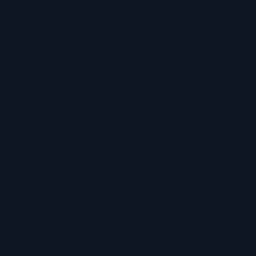

In [6]:
display(skycheck_map())

---
# ✈️ Will weather mess with my flight?
Worst airports first. Each card says **what's happening in plain English** and **why it matters**.
Tap *"For pilots"* on any card for the raw aviation report.

In [7]:
def card(r):
    st, pc = STATUS[r.status], PILOT_COLORS.get(r.cat, "#888")
    temp = f"{r.temp_f:.0f}°" if r.temp_f is not None and not pd.isna(r.temp_f) else "—"
    age = f"updated {r.age_min:.0f} min ago" if r.age_min is not None and not pd.isna(r.age_min) else "no report"
    reasons = "".join(f"<li>{_html.escape(x)}</li>" for x in r.reasons)
    vis = "10+ miles" if r.vis_mi and r.vis_mi >= 10 else (f"{r.vis_mi:g} miles" if r.vis_mi else "—")
    ceil = f"{r.ceiling_ft:,.0f} ft" if r.ceiling_ft and not pd.isna(r.ceiling_ft) else "none"
    return f"""
<div style="background:#fff;border-radius:14px;box-shadow:0 2px 10px rgba(0,0,0,.08);overflow:hidden;
            border-top:6px solid {st['color']};font-family:{FONT};color:#1d1d1f">
  <div style="padding:12px 14px 2px;display:flex;justify-content:space-between;align-items:flex-start">
    <div><div style="font-size:17px;font-weight:700">{_html.escape(r.name)}</div>
         <div style="font-size:12px;color:#777">{"<b style='color:#1f5f8b'>📍 near you</b> · " if r.icao in NEAR_ME else ""}{r.icao} · {age}</div></div>
    <div style="font-size:30px;font-weight:800;line-height:1">{temp}</div></div>
  <div style="margin:8px 14px 6px;padding:6px 10px;border-radius:8px;background:{st['bg']};color:{st['color']};
              font-weight:700;font-size:15px">{st['emoji']} {st['label']}</div>
  <div style="padding:0 14px;font-size:13px;color:#333">{r.sky} · 💨 {wind_text(r)}</div>
  <ul style="margin:6px 0 8px 30px;padding:0;font-size:13px;color:#444">{reasons}</ul>
  <details style="padding:0 14px 12px;font-size:12px;color:#666">
    <summary style="cursor:pointer">For pilots: <b style="color:{pc}">{r.cat}</b></summary>
    Ceiling {ceil} · visibility {vis}<br><code style="white-space:pre-wrap;font-size:11px">{_html.escape(r.raw)}</code>
  </details>
</div>"""

# problems get full cards; fine airports collapse into compact chips so the problems jump out
fine = airports[airports.status == "good"]
fine_row = ("" if fine.empty else
    f"<div style='font:600 13px {FONT};color:#555;margin:16px 0 6px'>✅ No weather worries at these airports</div>"
    "<div style='display:flex;flex-wrap:wrap;gap:8px'>" + "".join(
        f"<span title='{_html.escape(r.raw)}' style='background:#fff;border-left:4px solid {STATUS['good']['color']};"
        f"border-radius:8px;padding:6px 10px;box-shadow:0 1px 6px rgba(0,0,0,.07);font:13px {FONT};color:#333'>"
        f"<b>{_html.escape(r.name)}</b> {r.temp_f:.0f}° · {r.sky.lower()} · {wind_text(r)}</span>"
        for r in fine.itertuples()) + "</div>")
counts = airports.status.value_counts()
summary = " · ".join(f"{STATUS[s]['emoji']} <b>{counts[s]}</b> {txt}" for s, txt in
                     [("bad", "likely delays"), ("watch", "possible delays"), ("good", "look fine"), ("unknown", "no data")]
                     if counts.get(s, 0))
display(HTML(f"""
<div style="font:15px {FONT};margin:4px 0 12px">{summary}</div>
<div style="display:grid;grid-template-columns:repeat(auto-fill,minmax(250px,1fr));gap:12px">
  {''.join(card(r) for r in airports.itertuples() if r.status != "good")}
</div>
{fine_row}
<div style="font:12px {FONT};color:#777;margin-top:10px">Weather is only part of the story — ground stops and
air-traffic programs show up on the <a href="https://nasstatus.faa.gov" target="_blank">FAA airport status map</a>
and in your airline's app.</div>"""))

## ⏱️ Next 24 hours at your airports
Built from each airport's official forecast (TAF). Read it like a timeline: **find your flight time on the bottom, look up to your airport.** "Possible" forecast periods (TEMPO/PROB) count, so this errs on the side of warning you.

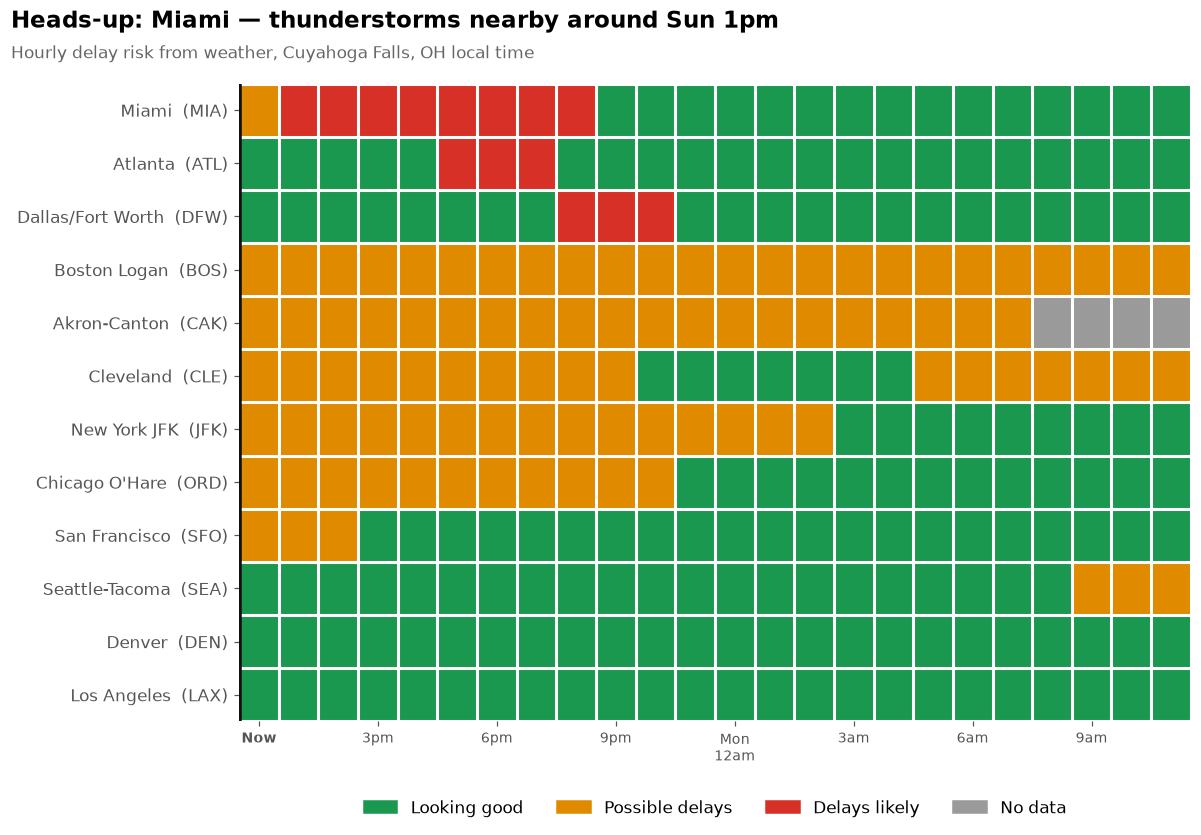

In [8]:
if outlook.empty:
    display(HTML(f"<div style='font:14px {FONT}'>No airport forecasts available right now.</div>"))
else:
    def _key(i):
        row = [RANK[x] for x in outlook.loc[i]]; w = max(row)
        return (-w, row.index(w) if w > 0 else 99, i)
    outlook = outlook.loc[sorted(outlook.index, key=_key)]
    order = ["unknown", "good", "watch", "bad"]
    cmap = ListedColormap([STATUS[s]["color"] for s in order])
    vals = outlook.replace({s: i for i, s in enumerate(order)}).astype(float).values
    names = [f"{airport_name(i)}  ({i[1:] if i.startswith('K') else i})" for i in outlook.index]
    fig, ax = plt.subplots(figsize=(11, 0.42 * len(names) + 2.3))
    ax.imshow(vals, aspect="auto", cmap=cmap, vmin=-.5, vmax=3.5, interpolation="nearest")
    ax.set_xticks(np.arange(-.5, vals.shape[1], 1), minor=True); ax.set_yticks(np.arange(-.5, vals.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2, alpha=1); ax.grid(which="major", visible=False)
    ax.tick_params(which="minor", length=0)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=11)
    loc_hours = [local(h) for h in outlook.columns]
    ticks = [0] + [i for i, h in enumerate(loc_hours) if h.hour % 3 == 0 and i > 1]
    ax.set_xticks(ticks)
    ax.set_xticklabels(["Now"] + [hr_label(loc_hours[i], loc_hours[i].hour == 0).replace(" ", "\n") for i in ticks[1:]],
                       fontsize=9)
    ax.get_xticklabels()[0].set_fontweight("bold")
    ax.axvline(-.5, color="#111", lw=3)
    for sp in ax.spines.values(): sp.set_visible(False)
    probs = sorted(outlook_notes.items(), key=lambda kv: (-RANK[kv[1][0]], kv[1][1]))
    if probs:
        i, (s, t, why) = probs[0]
        when = "right now" if t == outlook.columns[0] else f"around {hr_label(local(t))}"
        head = f"Heads-up: {airport_name(i)} — {why.lower()} {when}"
    else:
        head = "Smooth skies: no weather issues forecast at your airports for 24 hours"
    fig.text(0.01, 1.0, head, fontsize=15, fontweight="bold", ha="left", va="bottom", transform=fig.transFigure)
    fig.text(0.01, 0.985, f"Hourly delay risk from weather, {HOME_NAME} local time", fontsize=11, color="#666",
             ha="left", va="top", transform=fig.transFigure)
    ax.legend(handles=[Patch(color=STATUS[s]["color"], label=STATUS[s]["label"]) for s in ("good", "watch", "bad", "unknown")],
              loc="upper center", bbox_to_anchor=(0.5, -0.1 if len(names) > 6 else -0.25), ncol=4, frameon=False)
    plt.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

    if probs:
        items = "".join(f"<li>{STATUS[s]['emoji']} <b>{airport_name(i)}</b> — {why.lower()}, "
                        + ("<b>happening now</b>" if t == outlook.columns[0] else f"starting around <b>{hr_label(local(t))}</b>")
                        + "</li>" for i, (s, t, why) in probs)
        display(HTML(f"<ul style='font:14px/1.6 {FONT}'>{items}</ul>"))

---
# 🛸 When's the best time to be outside near home?
The next 48 hours, hour by hour. The **strip at the bottom is the answer**; the panels above explain it. The green band marks the next stretch where everything lines up; every good stretch is labeled on the strip — handy for a drone flight, a run, yard work or a photo shoot.
Drone limits come from your settings cell. *(Flying a drone? Also check airspace with the FAA's [B4UFLY](https://www.faa.gov/uas/getting_started/b4ufly) before you launch.)*

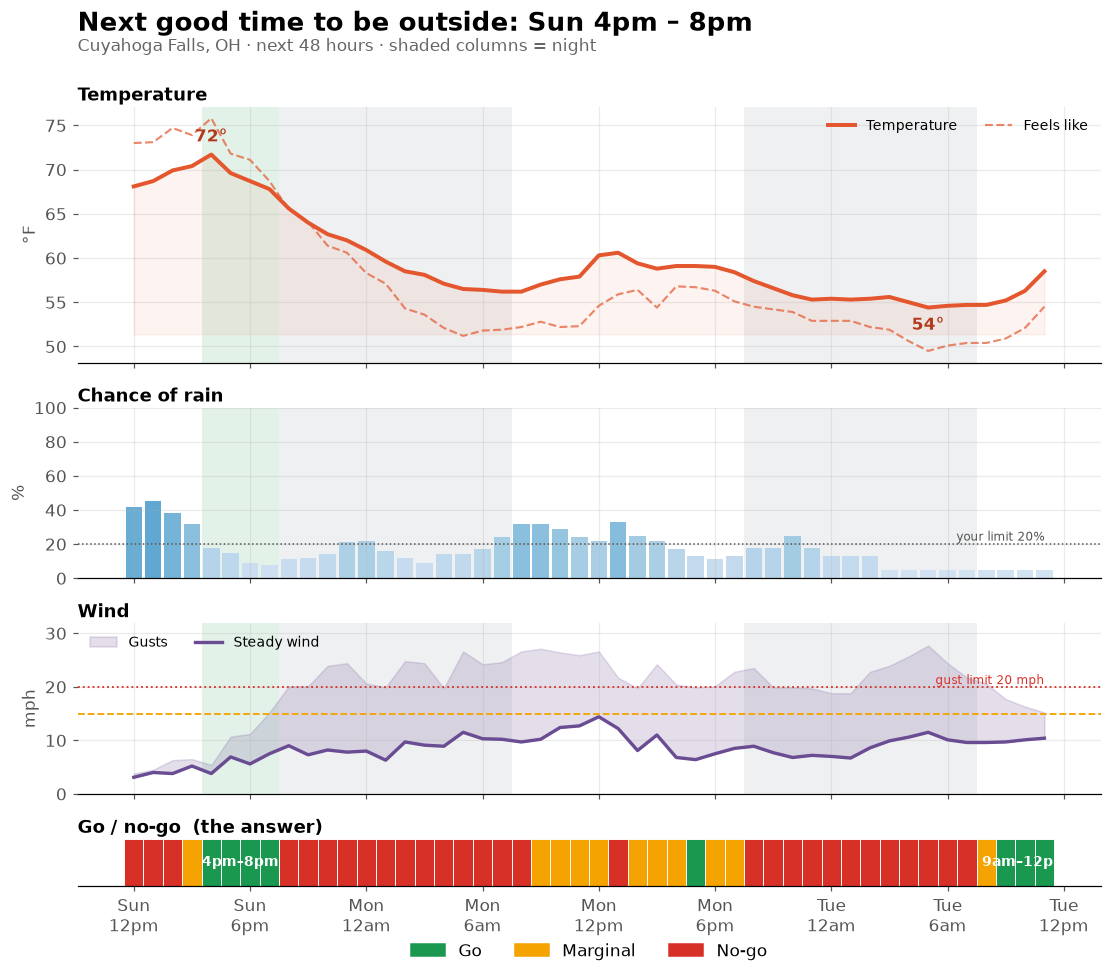

In [9]:
h = home
t = h.time
fig = plt.figure(figsize=(12, 9.2))
gs = fig.add_gridspec(4, 1, height_ratios=[3, 2, 2, .55], hspace=.28)
axT, axR, axW, axV = [fig.add_subplot(gs[i]) for i in range(4)]
for ax in (axR, axW, axV): ax.sharex(axT)
half = timedelta(minutes=30)

# night shading + next good window on every panel
win, longest = go_windows(h)
for ax in (axT, axR, axW):
    for i, r in h.iterrows():
        if not r.is_day: ax.axvspan(r.time - half, r.time + half, color="#1f2d3d", alpha=.07, lw=0)
    if win: ax.axvspan(t[win[0]] - half, t[win[1]] + half, color=GO["go"][0], alpha=.12, lw=0)

# 1) temperature
axT.plot(t, h.temperature_2m, color="#e4572e", lw=2.6, label="Temperature")
axT.plot(t, h.apparent_temperature, color="#e4572e", lw=1.4, ls="--", alpha=.7, label="Feels like")
axT.fill_between(t, h.temperature_2m, h.temperature_2m.min() - 3, color="#e4572e", alpha=.07)
for idx, va, off in ((h.temperature_2m.idxmax(), "bottom", 6), (h.temperature_2m.idxmin(), "top", -6)):
    axT.annotate(f"{h.temperature_2m[idx]:.0f}°", (t[idx], h.temperature_2m[idx]), textcoords="offset points",
                 xytext=(0, off), ha="center", va=va, fontsize=11, fontweight="bold", color="#b23a1b")
axT.set_ylabel("°F"); axT.legend(loc="upper right", frameon=False, ncol=2, fontsize=9)
axT.set_title("Temperature", pad=4)

# 2) rain chance
cols = plt.cm.Blues(np.clip(h.precipitation_probability / 100 * .85 + .15, 0, 1))
axR.bar(t, h.precipitation_probability, width=1 / 24 * .85, color=cols)
axR.axhline(DRONE["max_rain_chance"], color="#555", ls=":", lw=1)
axR.text(t.iloc[-1], DRONE["max_rain_chance"] + 2, f"your limit {DRONE['max_rain_chance']}%", ha="right", fontsize=8, color="#555")
axR.set_ylim(0, 100); axR.set_ylabel("%"); axR.set_title("Chance of rain", pad=4)

# 3) wind
axW.fill_between(t, h.wind_speed_10m, h.wind_gusts_10m, color="#6a4c93", alpha=.18, label="Gusts")
axW.plot(t, h.wind_speed_10m, color="#6a4c93", lw=2.2, label="Steady wind")
axW.axhline(DRONE["max_wind"], color="#f4a300", ls="--", lw=1.2)
axW.axhline(DRONE["max_gust"], color="#d73027", ls=":", lw=1.2)
axW.text(t.iloc[-1], DRONE["max_gust"] + .5, f"gust limit {DRONE['max_gust']} mph", ha="right", fontsize=8, color="#d73027")
axW.set_ylim(0, max(h.wind_gusts_10m.max() * 1.15, DRONE["max_gust"] + 5)); axW.set_ylabel("mph")
axW.legend(loc="upper left", frameon=False, ncol=2, fontsize=9); axW.set_title("Wind", pad=4)

# 4) verdict strip — the answer
for r in h.itertuples():
    axV.bar(r.time, 1, width=1 / 24, color=GO[r.verdict][0], edgecolor="white", linewidth=.6)
axV.set_yticks([]); axV.set_ylim(0, 1); axV.grid(False)
run = None
for i, v in enumerate(list(h.verdict) + ["end"]):
    if v == "go" and run is None: run = i
    elif v != "go" and run is not None:
        if i - run >= 3:
            mid = t[run] + (t[i - 1] - t[run]) / 2
            axV.text(mid, .5, f"{hr_label(t[run], False)}–{hr_label(t[i - 1] + timedelta(hours=1), False)}",
                     ha="center", va="center", color="white", fontsize=9, fontweight="bold")
        run = None
axV.set_title("Go / no-go  (the answer)", pad=4)
axV.legend(handles=[Patch(color=c, label=l) for c, l in GO.values()], loc="upper center", bbox_to_anchor=(.5, -.9),
           ncol=3, frameon=False)
axV.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
axV.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: hr_label(mdates.num2date(x).replace(tzinfo=None)).replace(" ", "\n")))
for ax in (axT, axR, axW): plt.setp(ax.get_xticklabels(), visible=False)

if win:
    head = f"Next good time to be outside: {hr_label(t[win[0]])} – {hr_label(t[win[1]] + timedelta(hours=1), False)}"
else:
    head = "No ideal outdoor window in the next 48 hours"
fig.text(0.125, 0.955, head, fontsize=17, fontweight="bold")
fig.text(0.125, 0.935, f"{HOME_NAME} · next {len(h)} hours · shaded columns = night", fontsize=11, color="#666")
plt.show()

# plain-English "why not" for the next few no-go stretches
blocks, prev = [], None
for r in h.itertuples():
    if r.verdict != "go" and (prev is None or prev[0] != r.why):
        prev = [r.why, r.time, r.time, r.verdict]; blocks.append(prev)
    elif r.verdict != "go": prev[2] = r.time
    else: prev = None
blocks = [b for b in blocks if b[0] != "dark"][:5]
if blocks:
    li = "".join(f"<li><span style='color:{GO[v][0]}'>●</span> {hr_label(a)}–{hr_label(b + timedelta(hours=1), False)}: {w}</li>"
                 for w, a, b, v in blocks)
    display(HTML(f"<div style='font:14px/1.6 {FONT}'><b>Why not other times?</b><ul>{li}</ul></div>"))

---
# 🗓️ Where and when is the weather actually nice?
The past 12 months of real daily weather for each city. A **"nice day"** = high between your settings (65–85°F by default) and dry. The boxed cell is each city's best month — the "go visit then" answer. Your city is added automatically and shown in bold.

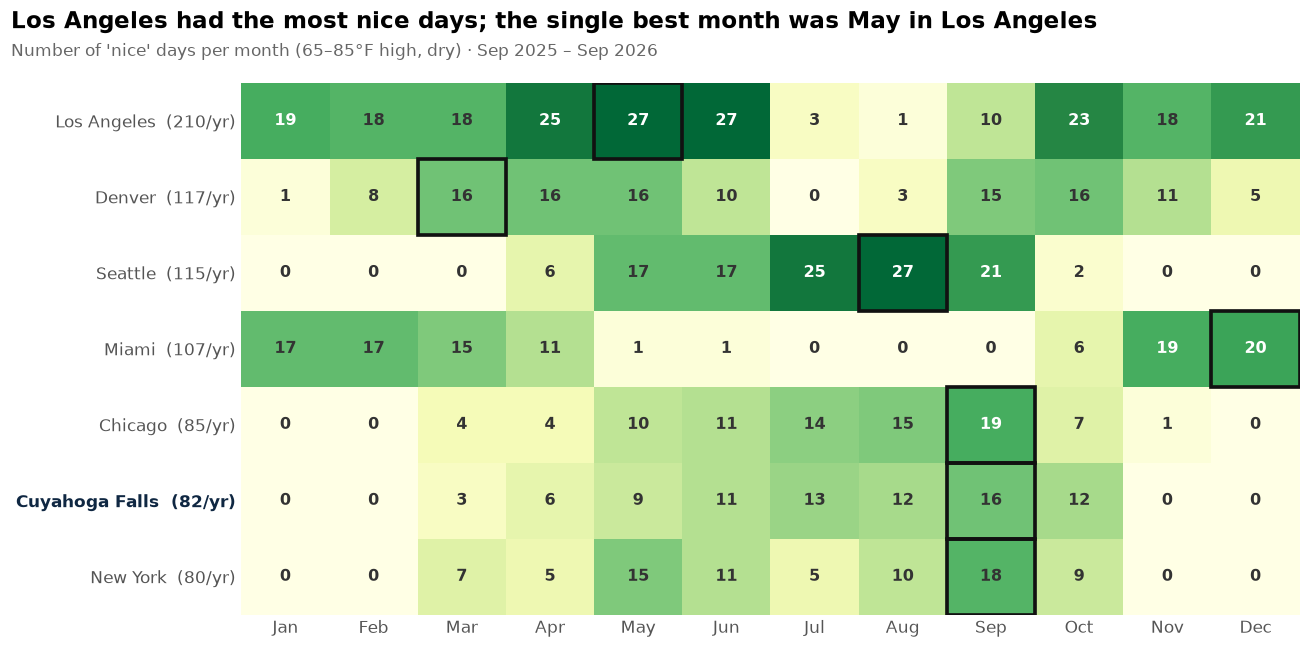

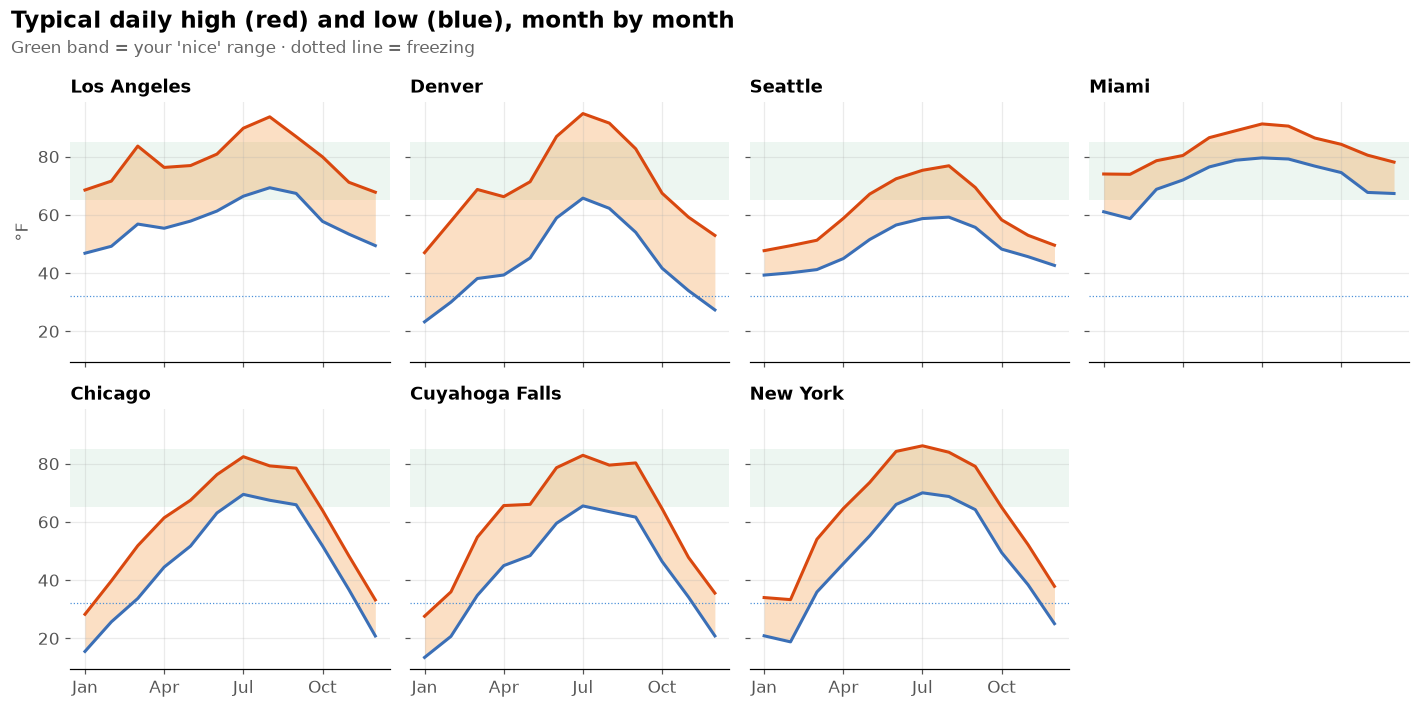

In [10]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
nice = climate.pivot(index="city", columns="month", values="nice").reindex(columns=range(1, 13)).fillna(0)
nice = nice.loc[nice.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 0.55 * len(nice) + 1.8))
ax.imshow(nice.values, cmap="YlGn", vmin=0, vmax=31, aspect="auto")
for (i, j), v in np.ndenumerate(nice.values):
    ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=10.5, fontweight="bold",
            color="white" if v > 18 else "#333")
for i, row in enumerate(nice.values):
    j = int(np.argmax(row))
    ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False, ec="#111", lw=2.4))
ax.set_xticks(range(12)); ax.set_xticklabels(MONTHS)
ax.set_yticks(range(len(nice))); ax.set_yticklabels([f"{c}  ({nice.loc[c].sum():.0f}/yr)" for c in nice.index])
ax.grid(False); ax.tick_params(length=0)
for lab, c in zip(ax.get_yticklabels(), nice.index):
    if c == HOME_CITY: lab.set_fontweight("bold"); lab.set_color("#0f2742")
for sp in ax.spines.values(): sp.set_visible(False)
bc = nice.sum(axis=1).idxmax(); bi, bj = np.unravel_index(np.argmax(nice.values), nice.shape)
fig.text(0.01, 1.0, f"{bc} had the most nice days; the single best month was {MONTHS[bj]} in {nice.index[bi]}",
         fontsize=15, fontweight="bold", va="bottom")
fig.text(0.01, 0.985, f"Number of 'nice' days per month ({NICE_HIGH_MIN}–{NICE_HIGH_MAX}°F high, dry) · "
         f"{clim_start:%b %Y} – {clim_end:%b %Y}", fontsize=11, color="#666", va="top")
plt.tight_layout(rect=(0, 0, 1, .95)); plt.show()

# typical high/low ribbons, small multiples with a shared scale
cities = list(nice.index); nc = 4; nr = math.ceil(len(cities) / nc)
fig, axes = plt.subplots(nr, nc, figsize=(13, 3.1 * nr), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
x = np.arange(1, 13)
for ax, c in zip(axes, cities):
    d = climate[climate.city == c].set_index("month").reindex(x)
    ax.axhspan(NICE_HIGH_MIN, NICE_HIGH_MAX, color="#1a9850", alpha=.08, lw=0)
    ax.axhline(32, color="#4a90d9", lw=.8, ls=":")
    ax.fill_between(x, d.low, d.high, color="#f28e2b", alpha=.28, lw=0)
    ax.plot(x, d.high, color="#d9480f", lw=2); ax.plot(x, d.low, color="#3b6fb6", lw=2)
    ax.set_title(c, fontsize=12)
    ax.set_xticks([1, 4, 7, 10]); ax.set_xticklabels(["Jan", "Apr", "Jul", "Oct"])
for ax in axes[len(cities):]: ax.set_visible(False)
axes[0].set_ylabel("°F")
fig.text(0.01, 1.0, "Typical daily high (red) and low (blue), month by month", fontsize=15, fontweight="bold", va="bottom")
fig.text(0.01, 0.99, "Green band = your 'nice' range · dotted line = freezing", fontsize=11, color="#666", va="top")
plt.tight_layout(rect=(0, 0, 1, .96)); plt.show()

# superlatives — the fun, shareable part
by = climate.groupby("city")
w = climate[climate.month.isin([12, 1, 2])].groupby("city")
s = climate[climate.month.isin([6, 7, 8])].groupby("city")
awards = [
    ("😎", "Most nice days", nice.sum(axis=1).idxmax(), f"{nice.sum(axis=1).max():.0f} days/yr"),
    ("☀️", "Sunniest", by.sun.mean().idxmax(), f"{by.sun.mean().max():.1f} sunny hrs/day"),
    ("☔", "Rainiest", by.rain_days.sum().idxmax(), f"{by.rain_days.sum().max():.0f} wet days/yr"),
    ("🥶", "Coldest winter", w.low.mean().idxmin(), f"avg low {w.low.mean().min():.0f}°F"),
    ("🔥", "Hottest summer", s.high.mean().idxmax(), f"avg high {s.high.mean().max():.0f}°F"),
    ("🌤️", "Mildest winter", w.high.mean().idxmax(), f"avg high {w.high.mean().max():.0f}°F"),
]
cards = "".join(f"<div style='background:#fff;border-radius:14px;padding:12px 14px;box-shadow:0 2px 10px rgba(0,0,0,.08)'>"
                f"<div style='font-size:26px'>{e}</div><div style='font:600 12px {FONT};color:#777;text-transform:uppercase;"
                f"letter-spacing:.05em'>{t_}</div><div style='font:800 19px {FONT};color:#1d1d1f'>{c}</div>"
                f"<div style='font:13px {FONT};color:#555'>{v}</div></div>" for e, t_, c, v in awards)
display(HTML(f"<div style='display:grid;grid-template-columns:repeat(auto-fill,minmax(170px,1fr));gap:12px'>{cards}</div>"))

---
## 📖 Decoder ring
| You'll see | What it means |
|---|---|
| ✅ **Looking good** | Nothing weather-related should slow flights down. |
| ⚠️ **Possible delays** | Rain, low clouds, or gusty wind. Airports land fewer planes per hour — expect ripple delays at busy hubs. |
| 🛑 **Delays likely** | Thunderstorms, fog, ice, or very strong wind. Ground stops and cancellations become common. |
| **VFR / MVFR / IFR / LIFR** | The pilot's version of the same idea, based on cloud height and visibility — from clear (VFR, green) to fogged-in (LIFR, magenta). |
| **SIGMET** | An official NOAA warning for dangerous weather aloft. Convective SIGMETs = organized thunderstorms. |
| **TAF** | An airport's official 24–30 hour forecast. "TEMPO" and "PROB" parts mean *might happen for a while*. |

**Sources** (free, no keys): [NOAA Aviation Weather Center Data API](https://aviationweather.gov/data/api/) — observations, forecasts, SIGMETs · [Open-Meteo](https://open-meteo.com) — home forecast and historical archive · [LibreWXR](https://librewxr.net) (CC BY 4.0) with [RainViewer](https://www.rainviewer.com) fallback and NEXRAD via [Iowa Environmental Mesonet](https://mesonet.agron.iastate.edu) — radar · Esri — basemap and imagery · NASA GIBS — daily clouds.
*This is a planning aid, not an official flight briefing.*